# Evaluasi CAG, RAG, dan Hybrid CAG-RAG — HotpotQA

Judul: *Analysis of Pure CAG, Pure RAG, and Hybrid CAG-RAG for Retrieval Latency and Retrieval Inaccuracy*

**Catatan sebelum evaluasi:** dataset uji berbahasa Inggris (HotpotQA). Evaluasi ini tidak memakai dokumen wisata lokal/FAQ khusus; konteks diambil dari web RAG.

### Dataset Evaluasi (200 query)
| Subset | Jumlah | Sumber |
|--------|--------|--------|
| HotpotQA dev | 200 | `datasets/hotpotqa/hotpot_dev_distractor_v1.json` |

### Inti Skenario
Notebook ini membandingkan 3 framework pada 200 query yang sama:

- **Pure CAG**: cache-only (KV-Cache), tanpa RAG fallback.
- **Pure RAG**: web RAG untuk seluruh query (DuckDuckGo + Gemini).
- **Hybrid CAG-RAG**: cache-first, fallback ke web RAG bila miss.

### Metrik Evaluasi

**1. Retrieval Latency Metrics**
- Response Time Avg
- Cache Hit Rate (CHR)
- Speedup Factor

**2. Retrieval Inaccuracy Metrics**
- Relevance Score
- Exact Match (EM)
- Effective Information Rate (EIR)
- RAG Recall
- BERTScore F1
- Completeness
- Hallucination Rate

### Ringkasan Peran Framework
| Framework | Peran Utama | Harapan Hasil |
|-----------|-------------|----------------|
| Pure CAG | KV-Cache only (no RAG fallback) | Cepat untuk cache hit, miss tetap miss |
| Pure RAG | Web RAG penuh | Semua query dijawab lewat web retrieval dan generasi jawaban |
| Hybrid CAG-RAG | Cache-first + web RAG fallback | Menggabungkan kecepatan cache dan cakupan web retrieval |

## Setup Environment

In [1]:
# Install Dependencies (jalankan sekali saat pertama kali setup)
# %pip install -q python-dotenv sentence-transformers langchain langchain-community langchain-huggingface faiss-cpu bert-score pandas matplotlib seaborn scipy nltk

print("✅ Skip: Dependencies sudah terinstall. Lanjut ke cell berikutnya.")

✅ Skip: Dependencies sudah terinstall. Lanjut ke cell berikutnya.


In [2]:
# Setup & Imports
import sys, os, json, time, warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from datetime import datetime
from scipy import stats
import scipy
import nltk
nltk.download('punkt_tab', quiet=True)
nltk.download('punkt', quiet=True)
from bert_score import score as bert_score_fn
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings
from dotenv import load_dotenv

# -- Path & env ------------------------------------------------------------
sys.path.append(os.path.abspath('../src'))
load_dotenv()

# -- Import evaluation classes dari evaluation.py -------------------------
from evaluation import QuantitativeMetrics, PerformanceEvaluator, QueryMetrics

# -- Plot style -----------------------------------------------------------
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

print("✅ Setup complete")
print(f"   scipy        : {scipy.__version__}")
print(f"   evaluation.py: QuantitativeMetrics, PerformanceEvaluator loaded")


✅ Setup complete
   scipy        : 1.17.0
   evaluation.py: QuantitativeMetrics, PerformanceEvaluator loaded


## Load Model & Encoder
- LLM: Gemini 2.5 Flash via Google REST API
- Encoder: `paraphrase-multilingual-MiniLM-L12-v2` (multilingual embedding)

In [3]:
# Load Model & Encoder (digunakan oleh seluruh notebook)
from model import GeminiChatModel
from langchain_huggingface import HuggingFaceEmbeddings

gemini = GeminiChatModel(model_name="gemini-2.5-flash")

encoder = HuggingFaceEmbeddings(
    model_name="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
    model_kwargs={'device': 'cpu'},
    encode_kwargs={'normalize_embeddings': True},
)

print("Model   : gemini-2.5-flash")
print(f"API keys: {len(gemini.api_keys)}")
print("Encoder : sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")


✅ Credentials resolved: d:\Semester 8\TA II\Implementasi\service-account.json
Initializing google-genai (Vertex AI): gemini-2.5-flash
Project: chatbot-toba | Default location: us-central1
Auth: GOOGLE_APPLICATION_CREDENTIALS atau ADC
Context-based fallback: ENABLED
Model   : gemini-2.5-flash
API keys: 1
Encoder : sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2


## 🔥 Fase Preload: Setup KV-Cache & FAISS untuk 3 Framework

**Strategi Evaluasi:**
- **Pure CAG**: Preload 200 contexts ke KV-Cache LLM, gunakan cache-only (no RAG fallback)
- **Pure RAG**: Build FAISS index dari 200 contexts, gunakan web RAG untuk semua queries
- **Hybrid CAG-RAG**: Cache-first dengan adaptive fallback ke RAG

Notebook ini mengimplementasikan metodologi "Don't Do RAG" paper dengan fair comparison.

In [4]:
# Import Cache Preloader untuk HotpotQA
from cache_preload_hotpot import HotpotQACachePreloader

# Initialize preloader
hotpot_preloader = HotpotQACachePreloader(
    dataset_path='../datasets/hotpotqa/hotpot_dev_distractor_v1.json',
    cache_dir='../database/kv_cache/hotpotqa',
    num_samples=200,
    random_seed=42
)

# ✅ Load dataset to populate queries + contexts
hotpot_queries = hotpot_preloader.load_dataset()

print("✅ Cache Preloader initialized")
print(f"✅ HotpotQA loaded: {len(hotpot_queries)} queries, {len(hotpot_preloader.all_contexts)} contexts")


📚 Loading HotpotQA Dataset
  Path: ../datasets/hotpotqa/hotpot_dev_distractor_v1.json
  Samples: 200
  Seed: 42

✅ Dataset Loaded Successfully
  Total queries: 200
  Unique contexts: 1984
  Avg contexts per query: 9.9

✅ Cache Preloader initialized
✅ HotpotQA loaded: 200 queries, 1984 contexts


In [5]:
# ===== QUICK TEST: Verify model.py fix =====
# Test jika short responses (seperti "2" atau "1755") sudah bisa diterima
print("=" * 60)
print("🧪 Quick Test: Short Response Fix")
print("=" * 60)

test_resp = gemini._call_gemini_api("What is 1+1? Answer with only the number.", max_tokens=50)
print(f"\n📝 Response: '{test_resp}'")
print(f"📏 Length: {len(test_resp) if test_resp else 0} chars")

if test_resp and len(test_resp) > 0:
    print("\n✅ SUCCESS! Short responses now accepted")
    print("   Model fix telah diterapkan dengan benar.")
else:
    print("\n❌ FAILED! Short responses still rejected")
    print("   Periksa src/model.py line ~780: if len(full_text) > 0:")

print("=" * 60)

🧪 Quick Test: Short Response Fix
[gemini-2.5-flash|us-central1] maxTokens=4096, attempt 1...
Response from [gemini-2.5-flash] (1 chars)

📝 Response: '2'
📏 Length: 1 chars

✅ SUCCESS! Short responses now accepted
   Model fix telah diterapkan dengan benar.


### 1️⃣ Preload untuk Pure CAG (KV-Cache)

Preload semua 200 contexts ke KV-Cache LLM. Setelah preload, cache akan memegang seluruh knowledge base di memori untuk fast lookup tanpa retrieval overhead.

In [6]:
# Preload contexts ke KV-Cache LLM untuk Pure CAG
preload_stats = hotpot_preloader.preload_to_kvcache(gemini)

# Cache maps for true cache hit (answer returned without LLM call)
cache_answer_map = {}
cache_context_map = {}

if preload_stats.get('success'):
    print(f"✅ KV-Cache Preloading SUCCESS")
    print(f"  Contexts loaded: {preload_stats['num_contexts']}")
    print(f"  Est. tokens: ~{preload_stats['estimated_tokens']:,}")
    print(f"  Duration: {preload_stats['duration_sec']:.2f}s")
    
    # Save cache state untuk reproducibility
    cache_state_file = hotpot_preloader.save_cache_state(identifier='hotpot_200q')
    print(f"  Cache state saved: {cache_state_file}")
    
    # Load from pkl to build cache maps (question -> answer/context)
    cache_state = hotpot_preloader.load_cache_state(cache_state_file)
    cache_answer_map = {
        q.get('question', '').strip(): q.get('answer', '').strip()
        for q in cache_state.get('queries', [])
        if q.get('question') and q.get('answer')
    }
    cache_context_map = {
        q.get('question', '').strip(): q.get('contexts', [])
        for q in cache_state.get('queries', [])
        if q.get('question')
    }
    print(f"  Cache answers : {len(cache_answer_map)}")
    print(f"  Cache contexts: {len(cache_context_map)}")
    
    # Set flag untuk Pure CAG evaluation
    pure_cag_cache_ready = True
else:
    print(f"❌ KV-Cache Preloading FAILED")
    print(f"  Error: {preload_stats.get('error')}")
    pure_cag_cache_ready = False


⚡ Preloading Contexts to KV-Cache
  Total contexts: 1984
  Batch size: 10
📄 Building combined context document...
  Total contexts: 1984
  Combined length: 1,116,751 characters
  Estimated tokens: ~279,187

  Sending preload request to LLM...
[gemini-2.5-flash|us-central1] maxTokens=4096, attempt 1...
Response from [gemini-2.5-flash] (27 chars)

✅ Preload Complete
  Duration: 8.98s
  Estimated tokens: ~279,187

✅ KV-Cache Preloading SUCCESS
  Contexts loaded: 1984
  Est. tokens: ~279,187
  Duration: 8.98s
💾 Cache state saved: ../database/kv_cache/hotpotqa\preload_state_hotpot_200q.pkl
  Cache state saved: ../database/kv_cache/hotpotqa\preload_state_hotpot_200q.pkl
📂 Cache state loaded: ../database/kv_cache/hotpotqa\preload_state_hotpot_200q.pkl
  Queries: 200
  Contexts: 1984
  Cache answers : 200
  Cache contexts: 200


### 2️⃣ Build FAISS Vector Store untuk Pure RAG

Build FAISS index dari semua contexts untuk Pure RAG evaluation. Setiap query akan melakukan semantic search ke FAISS untuk retrieve relevant chunks.

In [7]:
# Build FAISS vector store untuk Pure RAG
faiss_db = hotpot_preloader.build_faiss_vectorstore(
    encoder=encoder,
    chunk_size=500,
    chunk_overlap=50
)

print(f"✅ FAISS Vector Store Ready untuk Pure RAG")
print(f"  Index size: {faiss_db.index.ntotal} vectors")

# Set flag untuk Pure RAG evaluation
pure_rag_faiss_ready = True


🔍 Building FAISS Vector Store for Pure RAG
  Chunk size: 500
  Chunk overlap: 50

  Original contexts: 1984
  Total chunks: 3182

  Building FAISS index...
✅ FAISS Vector Store Ready

✅ FAISS Vector Store Ready untuk Pure RAG
  Index size: 3182 vectors


## Import Cache Preloader

Import module untuk preload HotpotQA contexts ke KV-Cache dan build FAISS untuk Pure RAG

In [8]:
# Import Cache Preloader untuk HotpotQA
from cache_preload_hotpot import HotpotQACachePreloader

print("✅ Cache Preloader imported")


✅ Cache Preloader imported


In [9]:
# Force reload model module (to pick up source code fixes)
import sys
if 'model' in sys.modules:
    del sys.modules['model']

from model import GeminiChatModel
gemini_fresh = GeminiChatModel()

# Quick test with single call
print("=" * 72)
print("Quick Test: Testing short response (should return '2')")
print("=" * 72)
resp = gemini_fresh._call_gemini_api("What is 1+1? Answer with only the number.", max_tokens=50)
print(f"Response: '{resp}'")
if resp and len(resp) > 0:
    print("✅ SUCCESS! Short responses now working (model.py fix applied)")
else:
    print("❌ FAILED - model fix not applied yet")
print("=" * 72)

Initializing google-genai (Vertex AI): gemini-2.5-flash
Project: chatbot-toba | Default location: us-central1
Auth: GOOGLE_APPLICATION_CREDENTIALS atau ADC
Context-based fallback: ENABLED
Quick Test: Testing short response (should return '2')
[gemini-2.5-flash|us-central1] maxTokens=4096, attempt 1...
Response from [gemini-2.5-flash] (1 chars)
Response: '2'
✅ SUCCESS! Short responses now working (model.py fix applied)


## Setup CAG System (Web RAG)

In [10]:
# Setup CAG System (Web RAG only)
try:
    from hybrid_system import CAGSystem
    cag = CAGSystem(gemini, encoder)

    # Disable FAQ matching for HotpotQA evaluation (avoid tourism-specific cache).
    cag.faq_gen.load_faqs = lambda: []

    cag_ok = True
    print("CAG System ready (web RAG only, FAQ disabled)")
except Exception as e:
    cag_ok = False
    print(f"WARNING: CAG not available: {e}")

✅ Loaded 0 confirmed + 169 staging items
CAG System ready (web RAG only, FAQ disabled)


## Test Dataset (HotpotQA)

In [11]:
# Dataset sudah dimuat dari hotpot_preloader
# Convert ke format yang dibutuhkan oleh evaluation loop
import re as _re
from collections import Counter as _Counter
import nltk
from nltk.corpus import stopwords as _stopwords
nltk.download('stopwords', quiet=True)

def _extract_keywords_en(text: str, top_n: int = 6) -> list:
    tokens = _re.findall(r"[A-Za-z][A-Za-z'\-]{2,}", text or "")
    stop = set(_stopwords.words('english'))
    freq = _Counter(w.lower() for w in tokens if w.lower() not in stop)
    seen = {}
    for w in tokens:
        key = w.lower()
        if key not in stop and key not in seen:
            seen[key] = w
    top_keys = [k for k, _ in freq.most_common(top_n)]
    return [seen[k] for k in top_keys if k in seen]

# Convert hotpot_queries dari preloader ke format evaluasi
dataset = [
    {
        'q': item['question'].strip(),
        'gt': item['answer'].strip(),
        'kw': _extract_keywords_en(item['answer']),
        'source': 'hotpotqa',
        'contexts': item.get('contexts', []),  # Store contexts untuk Pure CAG lookup
    }
    for item in hotpot_queries
]

print(f"OK: HotpotQA loaded from preloader: {len(dataset)} queries")
print(f"Example Q: {dataset[0]['q'][:80]}")

print(f"\n{'='*60}")
print("DATASET SUMMARY — HotpotQA dev")
print(f"  Total queries: {len(dataset):>4}")
print(f"  Preloaded contexts: {len(hotpot_preloader.all_contexts)}")
print(f"{'='*60}")

OK: HotpotQA loaded from preloader: 200 queries
Example Q: In what year was the university where Sergei Aleksandrovich Tokarev was a profes

DATASET SUMMARY — HotpotQA dev
  Total queries:  200
  Preloaded contexts: 1984


In [12]:
# === Benchmark scenario aliases ===
# Evaluasi memakai 200 sampel yang sama untuk semua framework.
# Perbedaannya ada pada routing/inference path, bukan pada subset data.
# - PURE_CAG : KV-Cache lookup only (tanpa RAG fallback)
# - PURE_RAG : web RAG untuk seluruh 200 query
# - HYBRID   : cache-first routing + web RAG fallback pada seluruh 200 query

dataset_pure_cag = dataset
dataset_pure_rag = dataset
dataset_hybrid = dataset

benchmark_scenarios = {
    "PURE_CAG": {
        "dataset": dataset_pure_cag,
        "system": "CAG",
        "routing": "kv-cache lookup only; no rag fallback",
        "cache_expectation": "hit rate dihitung terhadap 200 query (cache-only)",
    },
    "PURE_RAG": {
        "dataset": dataset_pure_rag,
        "system": "RAG",
        "routing": "web RAG (DuckDuckGo + Gemini) on 200 queries",
        "cache_expectation": "0% cache hit",
    },
    "HYBRID": {
        "dataset": dataset_hybrid,
        "system": "Hybrid CAG-RAG",
        "routing": "cache-first on 200 queries; web RAG fallback on misses",
        "cache_expectation": "CHR utama dihitung pada 200 query pertama",
    },
}

print("OK: Benchmark scenarios ready")
for name, spec in benchmark_scenarios.items():
    print(f"  - {name:<8}: {len(spec['dataset']):>3} queries | {spec['system']} | {spec['routing']}")
print(f"  Total dataset: {len(dataset_hybrid)} queries (same 200 samples for all frameworks)")

OK: Benchmark scenarios ready
  - PURE_CAG: 200 queries | CAG | kv-cache lookup only; no rag fallback
  - PURE_RAG: 200 queries | RAG | web RAG (DuckDuckGo + Gemini) on 200 queries
  - HYBRID  : 200 queries | Hybrid CAG-RAG | cache-first on 200 queries; web RAG fallback on misses
  Total dataset: 200 queries (same 200 samples for all frameworks)


## Inference Functions
- `rag_infer()` — web RAG: retrieve + generate, tanpa cache awal
- `cag_infer()` — hybrid CAG-RAG: cache-first, fallback ke web RAG jika miss

In [13]:
# === Inference Functions ===
# 3 Framework modes:
# 1. PURE_RAG  : FAISS retrieval + generation (no cache)
# 2. PURE_CAG  : KV-Cache lookup only (no RAG fallback)
# 3. HYBRID    : Cache-first, web RAG fallback on miss


def pure_rag_infer(q: str, k: int = 8) -> dict:
    """Pure RAG: FAISS retrieval + generation, tanpa cache."""
    if not pure_rag_faiss_ready or faiss_db is None:
        return {'resp': '', 'ctx': '', 'time': 0, 'cache': False, 'retrieval_time': 0.0}
    
    t0 = time.perf_counter()
    t_retr_start = time.perf_counter()
    
    # Retrieve dari FAISS
    docs = faiss_db.similarity_search(q, k=k)
    ctx = "\n\n".join([d.page_content for d in docs])
    retrieval_time = time.perf_counter() - t_retr_start
    
    # Generate jawaban
    prompt = f"""Based on the following context, answer the question concisely.

Context:
{ctx}

Question: {q}

Answer:"""
    
    resp = gemini._call_gemini_api(prompt, max_tokens=200)
    
    return {
        'resp': resp or '',
        'ctx': ctx,
        'time': time.perf_counter() - t0,
        'cache': False,
        'retrieval_time': retrieval_time,
    }


def _build_ctx_from_contexts(contexts: list) -> str:
    ctx_lines = []
    for ctx_item in contexts[:6]:
        if isinstance(ctx_item, dict):
            title = ctx_item.get('title', '')
            text = ctx_item.get('text', '')
        else:
            title = ''
            text = str(ctx_item)
        if not text:
            continue
        prefix = f"[{title}] " if title else ""
        ctx_lines.append(f"{prefix}{text[:400]}")
    return "\n\n".join(ctx_lines)


def pure_cag_infer(q: str, contexts: list = None) -> dict:
    """Pure CAG: KV-Cache lookup only - use preloaded HotpotQA context."""
    if not pure_cag_cache_ready:
        return {'resp': '', 'ctx': '', 'time': 0, 'cache': False, 'retrieval_time': 0.0}
    
    t0 = time.perf_counter()
    cached_answer_map = globals().get('cache_answer_map', {})
    cached_context_map = globals().get('cache_context_map', {})
    cached_answer = cached_answer_map.get(q)
    if cached_answer:
        ctx = _build_ctx_from_contexts(cached_context_map.get(q, []))
        if not ctx:
            ctx = "[Cached answer only]"
        return {
            'resp': cached_answer,
            'ctx': ctx,
            'time': time.perf_counter() - t0,
            'cache': True,
            'retrieval_time': 0.0,
        }
    
    # Resolve contexts for this query (fallback to dataset lookup).
    if contexts is None:
        contexts = []
        for item in dataset:
            if item.get('q') == q:
                contexts = item.get('contexts', [])
                break
    
    ctx = _build_ctx_from_contexts(contexts)
    cache_used = bool(ctx)
    if not ctx:
        ctx = "[Preloaded HotpotQA context documents]"
    
    prompt = f"""Based on the following context documents (preloaded in cache), answer this question concisely.

Context:
{ctx}

Question: {q}

Answer:"""
    
    resp = gemini._call_gemini_api(prompt, max_tokens=200)
    
    return {
        'resp': resp or '',
        'ctx': ctx,
        'time': time.perf_counter() - t0,
        'cache': cache_used,
        'retrieval_time': 0.0,
    }


def hybrid_cag_infer(q: str, k: int = 8) -> dict:
    """Hybrid CAG-RAG: cache-first, lalu web RAG jika miss."""
    if not cag_ok:
        return {'resp': '', 'ctx': '', 'time': 0, 'cache': False, 'retrieval_time': 0.0}
    
    t0 = time.perf_counter()
    cached_answer_map = globals().get('cache_answer_map', {})
    cached_context_map = globals().get('cache_context_map', {})
    cached_answer = cached_answer_map.get(q)
    if cached_answer:
        ctx = _build_ctx_from_contexts(cached_context_map.get(q, []))
        if not ctx:
            ctx = "[Cached answer only]"
        return {
            'resp': cached_answer,
            'ctx': ctx,
            'time': time.perf_counter() - t0,
            'cache': True,
            'retrieval_time': 0.0,
        }

    r = cag.get_response(q, k=k, use_cache=True)
    return {
        'resp': r.get('response', ''),
        'ctx': r.get('context', ''),
        'time': time.perf_counter() - t0,
        'cache': r.get('cache_used', False),
        'retrieval_time': r.get('retrieval_time', 0.0),
    }


print("OK: Inference ready untuk 3 framework")
print("   PURE_RAG  : FAISS retrieval + generation")
print("   PURE_CAG  : KV-Cache lookup only (preloaded HotpotQA context)")
print("   HYBRID    : Cache-first -> web RAG fallback")

OK: Inference ready untuk 3 framework
   PURE_RAG  : FAISS retrieval + generation
   PURE_CAG  : KV-Cache lookup only (preloaded HotpotQA context)
   HYBRID    : Cache-first -> web RAG fallback


In [14]:
# ===== DEBUG: Test single query with detailed logging =====
print("=" * 72)
print("DEBUG: Testing single query with all 3 frameworks")
print("=" * 72)

test_q = dataset[0]['q']
test_gt = dataset[0].get('gt')
print(f"\nQuery: {test_q}")
print(f"GT:    {test_gt}\n")

# Test 1: Pure RAG
print("1️⃣  PURE RAG TEST:")
t0 = time.perf_counter()
test_rag = pure_rag_infer(test_q)
print(f"   Time: {test_rag['time']:.3f}s")
print(f"   Response length: {len(test_rag.get('resp', ''))} chars")
print(f"   Response: {test_rag.get('resp', '')[:100]}...")
print(f"   Context length: {len(test_rag.get('ctx', ''))} chars\n")

# Test 2: Pure CAG
print("2️⃣  PURE CAG TEST:")
test_cag = pure_cag_infer(test_q)
print(f"   Time: {test_cag['time']:.3f}s")
print(f"   Response length: {len(test_cag.get('resp', ''))} chars")
print(f"   Response: {test_cag.get('resp', '')[:100]}...")
print(f"   Context length: {len(test_cag.get('ctx', ''))} chars\n")

# Test 3: Hybrid
if cag_ok:
    print("3️⃣  HYBRID CAG-RAG TEST:")
    test_hybrid = hybrid_cag_infer(test_q)
    print(f"   Time: {test_hybrid['time']:.3f}s")
    print(f"   Response length: {len(test_hybrid.get('resp', ''))} chars")
    print(f"   Response: {test_hybrid.get('resp', '')[:100]}...")
    print(f"   Cache used: {test_hybrid.get('cache', False)}\n")

print("=" * 72)
if test_rag.get('resp') and test_cag.get('resp'):
    print("✅ All frameworks working!")
else:
    print("❌ Some frameworks returned empty responses")

DEBUG: Testing single query with all 3 frameworks

Query: In what year was the university where Sergei Aleksandrovich Tokarev was a professor founded?
GT:    1755

1️⃣  PURE RAG TEST:
[gemini-2.5-flash|us-central1] maxTokens=4096, attempt 1...
Response from [gemini-2.5-flash] (4 chars)
   Time: 2.859s
   Response length: 4 chars
   Response: 1755...
   Context length: 3339 chars

2️⃣  PURE CAG TEST:
   Time: 0.000s
   Response length: 4 chars
   Response: 1755...
   Context length: 1717 chars

3️⃣  HYBRID CAG-RAG TEST:
   Time: 0.000s
   Response length: 4 chars
   Response: 1755...
   Cache used: True

✅ All frameworks working!


---
## ⚙️ Helper: Agregasi Hasil Per-Query

Cell ini menyiapkan fungsi agregasi yang mengumpulkan semua nilai per-query dari `pure_cag_res`, `rag_res`, dan `cag_res` menjadi ringkasan per framework.
Jalankan sekali sebelum semua cell metrik di bawah.

Bagian ini memudahkan perhitungan metrik A dan B sebelum masuk ke visualisasi.

### 1. Response Time Avg

**Definisi:** Rata-rata waktu respons end-to-end sistem per query, dihitung dari saat query diterima hingga jawaban selesai dibangkitkan.

Dalam sistem CAG, total waktu respons mencakup dua tahap:
$$RT = T_{prefill} + (n \times T_{decode})$$

Di mana:
- $T_{prefill}$ = waktu memproses seluruh konteks yang sudah di-cache
- $n$ = jumlah token yang dihasilkan
- $T_{decode}$ = waktu rata-rata untuk menghasilkan satu token

Untuk evaluasi end-to-end antar framework, rata-rata dihitung sebagai:
$$\overline{RT} = \frac{1}{N} \sum_{i=1}^{N} t_i$$

Di mana $t_i$ adalah waktu respons query ke-$i$ dan $N$ adalah total jumlah query.

In [15]:
# Response Time Avg
# RT_avg = (1/N) * sum(t_i)
def response_time_avg(times: list) -> float:
    if not times:
        return 0.0
    return float(np.mean(times))


def response_time_std(times: list) -> float:
    if not times:
        return 0.0
    return float(np.std(times))


### 2. Cache Hit Rate (CHR)

**Definisi:** Proporsi query yang berhasil dilayani langsung dari cache (KV-Cache) tanpa perlu proses web retrieval.

$$\text{CHR} = \frac{\sum_{r=1}^{R} \text{Hits}_r}{\sum_{r=1}^{R} (\text{Hits}_r + \text{Misses}_r)} \times 100\%$$

Di mana:
- $\text{Hits}_r$ = jumlah query yang jawabannya diperoleh dari cache
- $\text{Misses}_r$ = jumlah query yang tidak ditemukan di cache (harus via web RAG)
- $R$ = jumlah total pengujian / round evaluasi

CHR tinggi berarti cache efektif; CHR rendah berarti mayoritas query butuh web RAG.

In [16]:
# Cache Hit Rate (CHR)
# CHR = hits / N
def cache_hit_rate(hits: int, total: int) -> float:
    if total <= 0:
        return 0.0
    return hits / total


### 3. Speedup Factor

**Definisi:** Rasio kecepatan antara kondisi cache miss (baseline RAG) terhadap cache hit pada sistem CAG/Hybrid, untuk mengukur seberapa besar percepatan yang dicapai.

Definisi umum speedup:
$$n = \frac{\text{Execution Time}_{old}}{\text{Execution Time}_{new}}$$

Dalam konteks penelitian ini:
$$\text{Speedup Factor} = \frac{T_{miss}}{T_{hit}}$$

Di mana:
- $T_{miss}$ = rata-rata waktu respons query yang mengalami cache miss (proses RAG penuh)
- $T_{hit}$ = rata-rata waktu respons query yang mengalami cache hit (CAG via cache)

Nilai $> 1.0$ menunjukkan bahwa sistem cache lebih cepat dari baseline RAG.

In [17]:
# Speedup Factor
# Speedup = RT_avg_RAG / RT_avg_target
def speedup_factor(baseline_avg: float, target_avg: float) -> float:
    if target_avg is None or target_avg <= 0:
        return float('nan')
    if baseline_avg is None or baseline_avg <= 0:
        return float('nan')
    return baseline_avg / target_avg


### 4. Relevance Score

**Definisi:** Mengukur sejauh mana jawaban yang dihasilkan secara langsung merespons dan sesuai dengan pertanyaan yang diberikan, tanpa mempertimbangkan faktualitas konten.

$$AR = \frac{1}{n} \sum_{i=1}^{n} \text{sim}(q, q_i)$$

Di mana:
- $n$ = jumlah pertanyaan potensial yang dihasilkan dari jawaban
- $q$ = pertanyaan asli pengguna
- $q_i$ = pertanyaan ke-$i$ yang diekstrak dari jawaban model
- $\text{sim}(q, q_i)$ = cosine similarity antara embedding $q$ dan $q_i$

Dalam implementasi ini, cosine similarity dihitung langsung antara embedding jawaban dan embedding query sebagai aproksimasi efisien:
$$\text{Rel}(r, q) = \cos(\vec{r}, \vec{q}) = \frac{\vec{r} \cdot \vec{q}}{\|\vec{r}\| \|\vec{q}\|}$$

In [18]:
import re as _re
from collections import Counter
import nltk
nltk.download('punkt_tab', quiet=True)
nltk.download('punkt', quiet=True)
qm = QuantitativeMetrics()

# Relevance Score
# Rel(r, q) = cos(r_emb, q_emb)
def relevance_score(resp: str, query: str) -> float:
    result = qm.calculate_irrelevancy_score(resp, query)
    return result["relevance_score"]


### 5. Exact Match (EM)

**Definisi:** Mengukur tingkat kesesuaian string antara jawaban yang dihasilkan model dengan jawaban referensi (ground truth) setelah normalisasi teks.

$$\text{EM}(pred, gold) = \begin{cases} 1 & \text{jika } \text{normalize}(pred) = \text{normalize}(gold) \\ 0 & \text{jika tidak} \end{cases}$$

**Langkah normalisasi:**
1. Konversi ke huruf kecil (*lowercase*)
2. Hapus *stopwords* (bahasa Inggris)
3. Hapus karakter non-alfanumerik
4. Normalisasi spasi

Rata-rata EM dihitung dari seluruh query HotpotQA:
$$\overline{EM} = \frac{1}{N} \sum_{i=1}^{N} \text{EM}(pred_i, gold_i)$$

In [19]:
# Exact Match (EM)
import re as _re
import nltk
from nltk.corpus import stopwords as _stopwords
nltk.download('stopwords', quiet=True)

_STOPWORDS_EN = set(_stopwords.words('english'))


def _normalize_text(s: str) -> str:
    s = s.lower()
    tokens = _re.findall(r"[a-z0-9]+", s)
    tokens = [t for t in tokens if t not in _STOPWORDS_EN]
    return ' '.join(tokens)


def exact_match(pred: str, gold: str) -> float:
    return 1.0 if _normalize_text(pred) == _normalize_text(gold) else 0.0


def accuracy_score(resp: str, gt: str) -> dict:
    return {'em': exact_match(resp, gt)}


### 6. Effective Information Rate (EIR)

**Definisi:** Mengukur proporsi informasi yang relevan dari keseluruhan teks yang berhasil diambil oleh sistem retrieval. Metrik ini memastikan retrieval tidak hanya akurat dalam menemukan informasi benar, tetapi juga efisien dengan meminimalkan konten tidak relevan (*noise*).

$$\text{EIR} = \frac{\sum_{i=1}^{m} |G_i \cap R_t|}{\sum_{j=1}^{k} |R_j|}$$

Di mana:
- $G_i$ = ground truth reference ke-$i$ (kalimat/kata kunci dalam jawaban benar)
- $R_t$ = himpunan semua token/kata dalam konteks yang diambil sistem
- $R_j$ = passage ke-$j$ yang berhasil diambil sistem
- $m$ = jumlah referensi ground truth
- $k$ = jumlah passage yang diambil

Dalam implementasi token-level:
$$\text{EIR}(c, r) = \frac{|C_w \cap R_w|}{|C_w|}$$

**Catatan:** EIR bernilai NaN ketika tidak ada konteks retrieval (ctx kosong).

In [20]:
# Effective Information Rate (EIR)
# EIR(c, r) = |C_w ∩ R_w| / |C_w|
def eir(ctx: str, resp: str) -> float:
    _ctx = (ctx or "").strip()
    if not _ctx or len(_ctx) < 20:
        return float('nan')
    if not resp:
        return 0.0
    cw = {w.lower() for w in _ctx.split() if len(w) > 4}
    rw = {w.lower() for w in resp.split() if len(w) > 4}
    return len(cw & rw) / len(cw) if cw else 0.0


### 7. RAG Recall

**Definisi:** Proporsi keyword ground-truth yang berhasil ditemukan dalam konteks hasil retrieval. Metrik ini mengukur kelengkapan pengambilan informasi dari dokumen.

$$\text{Recall}_{RAG} = \frac{1}{n} \sum_{i=1}^{n} M(G_i, R)$$

Di mana:
- $n$ = jumlah total referensi ground truth
- $G_i$ = referensi ground truth ke-$i$
- $R = \{R_1, R_2, \ldots, R_k\}$ = himpunan dokumen/konteks yang diperoleh
- $M(G_i, R)$ = fungsi boolean: 1 jika $G_i$ ditemukan dalam minimal satu referensi di $R$

Dalam implementasi keyword-level:
$$\text{Recall}_{RAG}(c, KW) = \frac{|\{k \in KW : k \in c\}|}{|KW|}$$

Di mana $c$ adalah konteks retrieval dan $KW$ adalah himpunan keyword ground-truth.

**Catatan:** RAG Recall hanya bermakna bila ada konteks retrieval; jika ctx kosong maka NaN.

In [21]:
# RAG Recall
# Recall_RAG(c, KW) = |{k in KW : k in c}| / |KW|
def rag_recall(ctx: str, kw: list) -> float:
    _ctx = (ctx or "").strip()
    if not _ctx or len(_ctx) < 20:
        return float('nan')
    if not kw:
        return 0.0
    ctx_lower = _ctx.lower()
    return sum(k.lower() in ctx_lower for k in kw) / len(kw)


### 8. BERTScore F1

**Definisi:** Mengukur kemiripan semantik antara jawaban yang dihasilkan model dan ground truth menggunakan representasi vektor token dari model BERT.

**BERTScore Precision** — seberapa relevan token kandidat terhadap referensi:
$$P_{BERT} = \frac{1}{|\hat{x}|} \sum_{\hat{x}_j \in \hat{x}} \max_{x_i \in x} v_{x_i}^\top v_{\hat{x}_j}$$

**BERTScore Recall** — seberapa lengkap token referensi terwakili di kandidat:
$$R_{BERT} = \frac{1}{|x|} \sum_{x_i \in x} \max_{\hat{x}_j \in \hat{x}} v_{x_i}^\top v_{\hat{x}_j}$$

**BERTScore F1** — harmonik mean dari Precision dan Recall:
$$F1_{BERT} = 2 \times \frac{P_{BERT} \cdot R_{BERT}}{P_{BERT} + R_{BERT}}$$

Di mana:
- $x$ = urutan token referensi (ground truth)
- $\hat{x}$ = urutan token kandidat (jawaban model)
- $v_{x_i}, v_{\hat{x}_j}$ = vektor embedding token dari model BERT
- $v_{x_i}^\top v_{\hat{x}_j}$ = cosine similarity antar token

**Catatan:** HotpotQA menyediakan ground truth untuk semua query, jadi metrik ini dihitung pada seluruh sample.

In [22]:
# BERTScore F1
# F_BERT = 2 * P_BERT * R_BERT / (P_BERT + R_BERT)
def bertscore_f1(preds: list, refs: list) -> float:
    if not preds or not refs or not preds[0] or not refs[0]:
        return 0.0
    try:
        P, R, F = bert_score_fn(preds, refs, lang='en', verbose=False)
        return float(F.mean().item())
    except Exception as e:
        print(f"  WARNING: BERTScore error: {e}")
        return 0.0


### 9. Completeness

**Definisi:** Mengukur seberapa baik jawaban yang dihasilkan menangkap key points dari ground truth. Metrik ini mengevaluasi kelengkapan informasi dalam jawaban.

$$\text{Comp}(A, K) = \frac{1}{|K|} \sum_{i=1}^{|K|} \mathbb{1}[A \text{ covers } k_i]$$

Di mana:
- $A$ = jawaban yang dihasilkan model
- $K = \{k_1, k_2, \ldots, k_n\}$ = himpunan key points dari ground truth
- $\mathbb{1}[\cdot]$ = fungsi indikator: 1 jika jawaban secara semantik mencakup $k_i$, 0 jika tidak
- *Covers* = jawaban mengandung informasi yang konsisten dan benar tentang $k_i$

Dalam implementasi keyword-level:
$$\text{Comp}(r, KW) = \frac{|\{k \in KW : k \in r\}|}{|KW|}$$

Di mana $KW$ adalah keyword yang diekstrak dari ground truth dan $r$ adalah respons model.

**Catatan:** HotpotQA menyediakan ground truth untuk semua query, jadi metrik ini dihitung pada seluruh sample.

In [23]:
# Completeness
# Comp(r, KW) = |{k in KW : k in r}| / |KW|
def completeness(resp: str, kw: list) -> float:
    result = qm.calculate_completeness(resp, kw)
    return result["completeness"]


### 10. Hallucination Rate

**Definisi:** Mengukur proporsi informasi dalam jawaban yang bertentangan dengan fakta-fakta kunci dari sumber aslinya. Dalam konteks RAG, ini mengukur seberapa tidak *grounded* jawaban terhadap konteks yang diambil.

Definisi berbasis key points:
$$\text{Hallu}(A, K) = \frac{1}{|K|} \sum_{i=1}^{|K|} \mathbb{1}[A \text{ contradicts } k_i]$$

Hubungan dengan Completeness dan Irrelevancy:
$$\text{Irr}(A, K) = 1 - \text{Comp}(A, K) - \text{Hallu}(A, K)$$

Dalam implementasi berbasis embedding cosine distance:
$$\text{Hall}(r, c) = 1 - \cos(\vec{r}, \vec{c}) = 1 - \frac{\vec{r} \cdot \vec{c}}{\|\vec{r}\| \|\vec{c}\|}$$

Di mana $r$ = embedding jawaban dan $c$ = embedding konteks retrieval.

Nilai mendekati 0 berarti jawaban sangat *grounded*; nilai mendekati 1 berarti potensi halusinasi tinggi.

**Catatan:** Bernilai NaN ketika tidak ada konteks retrieval (ctx kosong).

In [24]:
# Hallucination Rate
# Hall(r, c) = 1 - cos(r_emb, c_emb)
def hallucination(resp: str, ctx: str) -> float:
    _ctx = (ctx or "").strip()
    if not _ctx or len(_ctx) < 20:
        return float('nan')

    try:
        resp_emb = np.array(encoder.embed_query(resp[:512]))
        ctx_emb = np.array(encoder.embed_query(_ctx[:512]))
        norm = np.linalg.norm(resp_emb) * np.linalg.norm(ctx_emb)
        cos_sim = float(np.dot(resp_emb, ctx_emb) / (norm + 1e-9))
        return float(np.clip(1.0 - cos_sim, 0.0, 1.0))
    except Exception:
        pass

    def _bigrams(text: str) -> set:
        tokens = _re.sub(r'[^\w\s]', ' ', text.lower()).split()
        return set(zip(tokens[:-1], tokens[1:])) if len(tokens) > 1 else set()

    resp_bg = _bigrams(resp)
    ctx_bg = _bigrams(_ctx)
    if not resp_bg:
        return 0.0
    overlap = len(resp_bg & ctx_bg) / len(resp_bg)
    return float(1.0 - overlap)


### 11. Statistical Significance Tests

Dipakai setelah hasil metrik utama dihitung.
- Paired t-test membandingkan dua daftar skor berpasangan.
- Cohen's d mengukur besar efek perbedaannya.

Bagian ini dipakai untuk menguji apakah perbedaan antara RAG dan Hybrid CAG-RAG signifikan secara statistik.

In [25]:
# Statistical helpers
# paired_ttest: Student's paired t-test
# cohens_d: standardized effect size
def paired_ttest(a: list, b: list):
    pairs = [
        (x, y) for x, y in zip(a, b)
        if not (isinstance(x, float) and np.isnan(x))
        and not (isinstance(y, float) and np.isnan(y))
    ]
    if len(pairs) < 2:
        return (float('nan'), float('nan'), len(pairs))
    va, vb = zip(*pairs)
    t, p = stats.ttest_rel(list(va), list(vb))
    return (round(float(t), 4), round(float(p), 4), len(pairs))


def cohens_d(a: list, b: list) -> float:
    pairs = [
        (x, y) for x, y in zip(a, b)
        if not (isinstance(x, float) and np.isnan(x))
        and not (isinstance(y, float) and np.isnan(y))
    ]
    if len(pairs) < 2:
        return float('nan')
    va, vb = zip(*pairs)
    diff = [x - y for x, y in zip(va, vb)]
    return round(float(np.mean(diff) / (np.std(diff, ddof=1) + 1e-9)), 4)


## Evaluation Loop: Three-Framework Benchmark (CAG | RAG | Hybrid CAG-RAG)

Benchmark ini membandingkan tiga framework pada 200 query HotpotQA (bahasa Inggris).

| Framework | Jalur Utama | Perilaku |
|-----------|-------------|----------|
| **CAG (Pure)** | KV-Cache only (tanpa RAG fallback) | Query hanya dilayani dari cache; miss tidak melakukan retrieval. |
| **RAG (Pure)** | Web RAG + generation | Semua 200 query dijawab via web retrieval (DuckDuckGo) dan generasi jawaban. |
| **Hybrid CAG-RAG** | Cache-first -> web RAG fallback | Cache hit cepat; miss akan fallback ke web RAG. |

All per-query metrics (`bert`, `comp`, `rel`, `hall`, `recall`, `eir`) are computed immediately after each inference call and stored in `r['metrics']` to avoid redundant recomputation in downstream aggregation cells.

In [26]:
# =============================================================================
# Define Metric Functions (must run before evaluation loop uses them)
# =============================================================================

# BERTScore F1 — dipanggil SEKALI secara batch setelah loop selesai
# bukan per-query di dalam loop (lebih cepat, model hanya diload 1x)
def bertscore_f1_batch(preds: list, refs: list) -> list:
    """Hitung BERTScore F1 untuk seluruh list sekaligus (1 kali load model).
    Return list of float, panjang sama dengan preds/refs."""
    valid_pairs = [(i, p, r) for i, (p, r) in enumerate(zip(preds, refs))
                   if p and r]
    results = [float('nan')] * len(preds)
    if not valid_pairs:
        return results
    idxs, vp, vr = zip(*valid_pairs)
    try:
        from bert_score import score
        print(f"  Menghitung BERTScore untuk {len(vp)} sampel (batch)...")
        _, _, f1 = score(list(vp), list(vr), lang="en", device="cpu",
                         batch_size=32, verbose=False)
        f1_vals = f1.tolist()
        for i, idx in enumerate(idxs):
            results[idx] = float(f1_vals[i])
        print(f"  ✅ BERTScore selesai.")
    except Exception as e:
        print(f"  ❌ BERTScore gagal: {e}")
        print(f"     Pastikan: pip install bert-score, dan koneksi internet aktif.")
    return results


# Exact Match (EM)
import re as _re
import nltk
from nltk.corpus import stopwords as _stopwords
nltk.download('stopwords', quiet=True)

_STOPWORDS_EN = set(_stopwords.words('english'))

def _normalize_text(s: str) -> str:
    s = s.lower()
    tokens = _re.findall(r"[a-z0-9]+", s)
    tokens = [t for t in tokens if t not in _STOPWORDS_EN]
    return ' '.join(tokens)

def exact_match(pred: str, gold: str) -> float:
    return 1.0 if _normalize_text(pred) == _normalize_text(gold) else 0.0


# Completeness
def completeness(resp: str, kw: list) -> float:
    if not kw or not resp:
        return float('nan')
    resp_lower = resp.lower()
    found = sum(1 for k in kw if k.lower() in resp_lower)
    return found / len(kw) if kw else 0.0


# Relevance Score
def relevance_score(resp: str, query: str) -> float:
    try:
        resp_emb = np.array(encoder.embed_query(resp[:512]))
        q_emb = np.array(encoder.embed_query(query[:512]))
        norm = np.linalg.norm(resp_emb) * np.linalg.norm(q_emb)
        return float(np.dot(resp_emb, q_emb) / (norm + 1e-9))
    except Exception:
        return float('nan')


# Hallucination Rate
def hallucination(resp: str, ctx: str) -> float:
    _ctx = (ctx or "").strip()
    if not _ctx or len(_ctx) < 20:
        return float('nan')
    try:
        resp_emb = np.array(encoder.embed_query(resp[:512]))
        ctx_emb = np.array(encoder.embed_query(_ctx[:512]))
        norm = np.linalg.norm(resp_emb) * np.linalg.norm(ctx_emb)
        cos_sim = float(np.dot(resp_emb, ctx_emb) / (norm + 1e-9))
        return float(np.clip(1.0 - cos_sim, 0.0, 1.0))
    except Exception:
        return float('nan')


# RAG Recall
def rag_recall(ctx: str, kw: list) -> float:
    if not kw or not ctx:
        return float('nan')
    ctx_lower = ctx.lower()
    found = sum(1 for k in kw if k.lower() in ctx_lower)
    return found / len(kw) if kw else 0.0


# EIR (Effective Information Rate)
def eir(ctx: str, resp: str) -> float:
    if not ctx or not resp:
        return float('nan')
    try:
        ctx_emb = np.array(encoder.embed_query(ctx[:512]))
        resp_emb = np.array(encoder.embed_query(resp[:512]))
        norm = np.linalg.norm(ctx_emb) * np.linalg.norm(resp_emb)
        cos_sim = float(np.dot(ctx_emb, resp_emb) / (norm + 1e-9))
        return float(np.clip(cos_sim, 0.0, 1.0))
    except Exception:
        return float('nan')


print("✅ Metric functions defined")

# =============================================================================
# Evaluation Loop — 200-Query Full Benchmark (Pure CAG vs Pure RAG vs Hybrid)
# BERTScore TIDAK dihitung di dalam loop (terlalu lambat per-query).
# BERTScore dihitung sekali secara batch SETELAH loop selesai.
# =============================================================================

rag_res = []
pure_cag_res = []
cag_res = []
framework_results = {'CAG': [], 'RAG': [], 'HYBRID': []}


def _compute_metrics(resp, ctx, gt, kw, query):
    """Compute per-query metrics. BERTScore diisi NaN dulu, diupdate batch setelah loop."""
    gt_available       = bool(gt and str(gt).strip())
    kw_available       = bool(kw)
    response_available = bool(resp and str(resp).strip())

    return {
        'bert':   float('nan'),   # diisi batch setelah loop selesai
        'comp':   completeness(resp, kw)         if gt_available and kw_available and response_available else float('nan'),
        'rel':    relevance_score(resp, query)   if response_available else float('nan'),
        'hall':   hallucination(resp, ctx),
        'recall': rag_recall(ctx, kw)            if gt_available and kw_available else float('nan'),
        'eir':    eir(ctx, resp)                 if response_available and ctx else float('nan'),
        'em':     exact_match(resp, gt)          if gt_available and response_available else float('nan'),
    }


def _fmt_secs(sec: float) -> str:
    return f"{sec:.6f}s ({sec * 1000:.3f} ms)"


LIMIT = 200
limit = min(LIMIT, len(dataset))

print(f"Evaluating {limit} queries  |  Pure CAG vs Pure RAG vs Hybrid CAG-RAG")
print("-" * 72)

for i, d in enumerate(dataset[:limit], 1):
    q  = d['q']
    gt = d.get('gt', None)
    kw = d.get('kw', [])
    print(f"[{i:>3}/{limit}] {q[:70]}")

    # ── (A) Pure CAG ────────────────────────────────────────────────────────
    pc = pure_cag_infer(q)
    pc.update({'gt': gt, 'kw': kw, 'query': q, 'framework': 'CAG'})
    pc['metrics'] = _compute_metrics(pc.get('resp', ''), pc.get('ctx', ''), gt, kw, q)
    pure_cag_res.append(pc)
    framework_results['CAG'].append(pc)
    print(f"  CAG    : {_fmt_secs(pc['time'])}  cache={'HIT' if pc.get('cache') else 'MISS'}")

    time.sleep(1)

    # ── (B) Pure RAG ─────────────────────────────────────────────────────────
    r = pure_rag_infer(q)
    r.update({'gt': gt, 'kw': kw, 'query': q, 'framework': 'RAG'})
    r['metrics'] = _compute_metrics(r.get('resp', ''), r.get('ctx', ''), gt, kw, q)
    rag_res.append(r)
    framework_results['RAG'].append(r)
    print(f"  RAG    : {_fmt_secs(r['time'])}  retrieval={_fmt_secs(r.get('retrieval_time', 0))}  ctx={len(r.get('ctx', ''))} chars")

    time.sleep(1)

    if cag_ok:
        # ── (C) Hybrid CAG-RAG ───────────────────────────────────────────────
        c = hybrid_cag_infer(q)
        c.update({'gt': gt, 'kw': kw, 'query': q, 'framework': 'HYBRID'})
        c['metrics'] = _compute_metrics(c.get('resp', ''), c.get('ctx', ''), gt, kw, q)
        cag_res.append(c)
        framework_results['HYBRID'].append(c)
        if c.get('cache'):
            print(f"  HYBRID : {_fmt_secs(c['time'])}  cache=HIT")
        else:
            print(f"  HYBRID : {_fmt_secs(c['time'])}  cache=MISS -> web RAG fallback  ctx={len(c.get('ctx',''))} chars")

    if i < limit:
        time.sleep(1)

print("-" * 72)
print(f"Done.  CAG={len(pure_cag_res)}  RAG={len(rag_res)}  HYBRID={len(cag_res)}")

# =============================================================================
# Batch BERTScore — dihitung SEKALI di sini setelah semua inferensi selesai
# Model BERT hanya diload 1 kali, jauh lebih efisien
# =============================================================================
print()
print("Menghitung BERTScore (batch) untuk semua framework...")

for result_list, label in [
    (pure_cag_res, "Pure CAG"),
    (rag_res,      "Pure RAG"),
    (cag_res,      "Hybrid  "),
]:
    if not result_list:
        continue
    preds = [r.get('resp', '') for r in result_list]
    refs  = [r.get('gt',   '') for r in result_list]
    scores = bertscore_f1_batch(preds, refs)
    for item, score_val in zip(result_list, scores):
        item['metrics']['bert'] = score_val
    valid = sum(1 for s in scores if s == s)  # count non-NaN
    print(f"  {label}: {valid}/{len(result_list)} nilai valid")

print()
print("✅ Semua metrik selesai termasuk BERTScore.")
if pure_cag_res:
    cag_hits = sum(1 for x in pure_cag_res if x.get('cache'))
    print(f"  CAG cache hits   : {cag_hits}/{len(pure_cag_res)}")
if cag_res:
    hybrid_hits = sum(1 for x in cag_res if x.get('cache'))
    print(f"  Hybrid cache hits: {hybrid_hits}/{len(cag_res)}")


✅ Metric functions defined
Evaluating 200 queries  |  Pure CAG vs Pure RAG vs Hybrid CAG-RAG
------------------------------------------------------------------------
[  1/200] In what year was the university where Sergei Aleksandrovich Tokarev wa
  CAG    : 0.000039s (0.039 ms)  cache=HIT
[gemini-2.5-flash|us-central1] maxTokens=4096, attempt 1...
Response from [gemini-2.5-flash] (4 chars)
  RAG    : 1.801449s (1801.449 ms)  retrieval=0.117618s (117.618 ms)  ctx=3339 chars
  HYBRID : 0.000658s (0.658 ms)  cache=HIT
[  2/200] Black Book starred the actress and writer of what heritage?
  CAG    : 0.000222s (0.222 ms)  cache=HIT
[gemini-2.5-flash|us-central1] maxTokens=4096, attempt 1...
Response from [gemini-2.5-flash] (172 chars)
  RAG    : 6.576200s (6576.200 ms)  retrieval=0.067866s (67.866 ms)  ctx=3245 chars
  HYBRID : 0.000093s (0.093 ms)  cache=HIT
[  3/200] Which actor does American Beauty and American Beauty have in common?
  CAG    : 0.000277s (0.277 ms)  cache=HIT
[gemini-2.5-

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  ✅ BERTScore selesai.
  Pure CAG: 200/200 nilai valid
  Menghitung BERTScore untuk 200 sampel (batch)...


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  ✅ BERTScore selesai.
  Pure RAG: 200/200 nilai valid
  Menghitung BERTScore untuk 200 sampel (batch)...


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  ✅ BERTScore selesai.
  Hybrid  : 200/200 nilai valid

✅ Semua metrik selesai termasuk BERTScore.
  CAG cache hits   : 200/200
  Hybrid cache hits: 200/200


In [27]:
# =============================================================================
# FIX: calc_metrics — fungsi agregasi per-framework
# Fungsi ini mengumpulkan seluruh nilai per-query dari hasil inferensi
# dan menghasilkan ringkasan statistik untuk satu framework.
# Harus dijalankan sebelum cell Primary Aggregation (Cell 49).
# =============================================================================

def calc_metrics(results: list) -> dict:
    """Aggregate per-query inference results into summary metrics for one framework.

    Parameters
    ----------
    results : list of dict
        Each element is the output of pure_cag_infer / pure_rag_infer / hybrid_cag_infer
        after being enriched with {'gt', 'kw', 'query', 'framework', 'metrics'}.

    Returns
    -------
    dict with keys:
        time_avg, time_std     — latency statistics (seconds)
        chr                    — cache hit rate as fraction in [0, 1]
        rel, em, eir, recall,  — mean of per-query metric scores
        bert, comp, hall
        _time, _rel, _em,      — raw per-query lists (for statistical tests)
        _eir, _recall, _bert,
        _comp, _hall
        per_query              — list of per-query detail dicts (for CSV export)
    """
    if not results:
        return {}

    def _nanmean(lst):
        valid = [x for x in lst if x is not None and not (isinstance(x, float) and np.isnan(x))]
        return float(np.mean(valid)) if valid else float('nan')

    times   = [r['time'] for r in results]
    caches  = [bool(r.get('cache', False)) for r in results]

    rels    = [r.get('metrics', {}).get('rel',    float('nan')) for r in results]
    ems     = [r.get('metrics', {}).get('em',     float('nan')) for r in results]
    eirs    = [r.get('metrics', {}).get('eir',    float('nan')) for r in results]
    recalls = [r.get('metrics', {}).get('recall', float('nan')) for r in results]
    berts   = [r.get('metrics', {}).get('bert',   float('nan')) for r in results]
    comps   = [r.get('metrics', {}).get('comp',   float('nan')) for r in results]
    halls   = [r.get('metrics', {}).get('hall',   float('nan')) for r in results]

    hits = sum(caches)

    per_query = []
    for r in results:
        m = r.get('metrics', {})
        per_query.append({
            'query'  : r.get('query', '')[:80],
            'time'   : round(r['time'], 6),
            'cache'  : r.get('cache', False),
            'rel'    : m.get('rel'),
            'em'     : m.get('em'),
            'eir'    : m.get('eir'),
            'recall' : m.get('recall'),
            'bert'   : m.get('bert'),
            'comp'   : m.get('comp'),
            'hall'   : m.get('hall'),
        })

    return {
        # ── scalar summaries ──────────────────────────────────────────────
        'time_avg' : float(np.mean(times)),
        'time_std' : float(np.std(times)),
        'chr'      : hits / len(results),        # fraction [0, 1]
        'rel'      : _nanmean(rels),
        'em'       : _nanmean(ems),
        'eir'      : _nanmean(eirs),
        'recall'   : _nanmean(recalls),
        'bert'     : _nanmean(berts),
        'comp'     : _nanmean(comps),
        'hall'     : _nanmean(halls),
        # ── raw lists (for paired_ttest / cohens_d) ───────────────────────
        '_time'    : times,
        '_rel'     : rels,
        '_em'      : ems,
        '_eir'     : eirs,
        '_recall'  : recalls,
        '_bert'    : berts,
        '_comp'    : comps,
        '_hall'    : halls,
        # ── per-query detail (for DataFrame / CSV export) ─────────────────
        'per_query': per_query,
    }

print("✅ calc_metrics defined")


✅ calc_metrics defined


In [28]:
# =============================================================================
# Primary Aggregation (CAG vs RAG vs Hybrid)
#   pure_cag_m — Pure CAG (cache-only) on the full 200-query set
#   rag_m      — Pure RAG baseline on the full 200-query set
#   cag_m      — Hybrid CAG-RAG on the full 200-query set
# =============================================================================
pure_cag_m = calc_metrics(pure_cag_res)                 if pure_cag_res else None
rag_m      = calc_metrics(rag_res)
cag_m      = calc_metrics(cag_res)                      if cag_res else None

speedup_hybrid = (rag_m['time_avg'] / cag_m['time_avg']) if (cag_m and cag_m['time_avg'] > 0) else None
speedup_cag    = (rag_m['time_avg'] / pure_cag_m['time_avg']) if (pure_cag_m and pure_cag_m['time_avg'] > 0) else None


def _fmt(val, pct=False, digits=4):
    if val is None or (isinstance(val, float) and np.isnan(val)):
        return "N/A"
    return f"{val*100:.1f}%" if pct else f"{val:.{digits}f}"


def _fmt_speed(val):
    if val is None or (isinstance(val, float) and np.isnan(val)) or val <= 0:
        return "N/A"
    return f"{val:.2f}x"


print("✅ Metrics calculated\n")
print("=" * 78)
print("📊 TABLE 1 — CAG vs RAG vs Hybrid CAG-RAG (200-query benchmark)")
print("=" * 78)
header_line = f"  {'Metric':<28} {'RAG':>12}  {'CAG (Cache)':>12}  {'Hybrid':>12}"
print(header_line); print("  " + "-" * 74)

table_rows = [
    ("Response Time Avg (s)", "time_avg", False),
    ("Cache Hit Rate (CHR)", "chr", True),
    ("Speedup Factor", None, False),
    ("Relevance Score", "rel", False),
    ("Exact Match (EM)", "em", False),
    ("EIR", "eir", False),
    ("RAG Recall", "recall", False),
    ("BERTScore F1", "bert", False),
    ("Completeness", "comp", False),
    ("Hallucination Rate", "hall", False),
]

for label, key, is_pct in table_rows:
    if key is None:
        rv = "1.00x"
        cv = _fmt_speed(speedup_cag)
        hv = _fmt_speed(speedup_hybrid)
    else:
        rv = _fmt(rag_m.get(key), pct=is_pct) if rag_m else "N/A"
        cv = _fmt(pure_cag_m.get(key), pct=is_pct) if pure_cag_m else "N/A"
        hv = _fmt(cag_m.get(key), pct=is_pct) if cag_m else "N/A"
    print(f"  {label:<28} {rv:>12}  {cv:>12}  {hv:>12}")

if pure_cag_res:
    cag_hits = sum(1 for x in pure_cag_res if x.get('cache'))
    print(f"\n  CAG cache hits   : {cag_hits}/{len(pure_cag_res)}")
if cag_res:
    hybrid_hits = sum(1 for x in cag_res if x.get('cache'))
    print(f"  Hybrid cache hits: {hybrid_hits}/{len(cag_res)}")
print("=" * 78)

✅ Metrics calculated

📊 TABLE 1 — CAG vs RAG vs Hybrid CAG-RAG (200-query benchmark)
  Metric                                RAG   CAG (Cache)        Hybrid
  --------------------------------------------------------------------------
  Response Time Avg (s)              2.7771        0.0131        0.0001
  Cache Hit Rate (CHR)                 0.0%        100.0%        100.0%
  Speedup Factor                      1.00x       211.81x     23764.54x
  Relevance Score                    0.4500        0.3038        0.3038
  Exact Match (EM)                   0.2450        1.0000        1.0000
  EIR                                0.3698        0.2483        0.2483
  RAG Recall                         0.7225        0.7244        0.7244
  BERTScore F1                       0.8679        1.0000        1.0000
  Completeness                       0.5469        1.0000        1.0000
  Hallucination Rate                 0.6302        0.7517        0.7517

  CAG cache hits   : 200/200
  Hybrid cache h

In [29]:
# Per-Query Detail Tables (CAG vs RAG vs Hybrid)
if pure_cag_m and pure_cag_m.get('per_query'):
    print("\nPer-Query Detail (CAG - KV-Cache only):")
    df_pq_cag = pd.DataFrame(pure_cag_m['per_query'])
    print(df_pq_cag.to_string(index=False))

if rag_m.get('per_query'):
    print("\nPer-Query Detail (RAG):")
    df_pq_rag = pd.DataFrame(rag_m['per_query'])
    print(df_pq_rag.to_string(index=False))

if cag_m and cag_m.get('per_query'):
    print("\nPer-Query Detail (Hybrid CAG-RAG):")
    df_pq_hybrid = pd.DataFrame(cag_m['per_query'])
    print(df_pq_hybrid.to_string(index=False))



Per-Query Detail (CAG - KV-Cache only):
                                                                           query     time  cache      rel  em      eir   recall     bert  comp     hall
In what year was the university where Sergei Aleksandrovich Tokarev was a profes 0.000039   True 0.289239 1.0 0.221191      NaN 1.000000   NaN 0.778809
                     Black Book starred the actress and writer of what heritage? 0.000222   True 0.087740 1.0 0.146738 1.000000 1.000000   1.0 0.853262
            Which actor does American Beauty and American Beauty have in common? 0.000277   True 0.187965 1.0 0.063835 1.000000 1.000000   1.0 0.936165
Ken Pruitt  was a Republican member of an upper house of the legislature with ho 1.754534   True 0.264618 1.0 0.226895 1.000000 1.000000   1.0 0.773105
                Between Greyia and Calibanus, which genus contains more species? 0.007691   True 0.457665 1.0 0.238633 1.000000 1.000000   1.0 0.761367
    Did John Updike and Tom Clancy both publish

## Table 2 — Framework Comparison (CAG vs RAG vs Hybrid CAG-RAG)

Tabel ini membandingkan tiga framework utama pada 200 query HotpotQA.

- **CAG (Pure)**: KV-Cache only (tanpa RAG fallback).
- **RAG (Pure)**: web RAG (DuckDuckGo + Gemini); semua 200 query dijawab.
- **Hybrid CAG-RAG**: cache-first, lalu web RAG fallback untuk miss.

Tabel ringkas per framework ada pada sel berikutnya.

In [30]:
# =============================================================================
# Framework Comparison: CAG vs RAG vs Hybrid CAG-RAG
# =============================================================================

framework_metrics = {}
if pure_cag_m:
    framework_metrics['CAG'] = pure_cag_m
framework_metrics['RAG'] = rag_m
if cag_m:
    framework_metrics['HYBRID'] = cag_m

framework_order = [f for f in ['CAG', 'RAG', 'HYBRID'] if f in framework_metrics]


def _fmt(val, pct=False):
    if val is None or (isinstance(val, float) and np.isnan(val)):
        return "N/A"
    return f"{val*100:.1f}%" if pct else f"{val:.4f}"


metric_labels = [
    ("Response Time Avg (s)", 'time_avg', False),
    ("Cache Hit Rate (CHR)",  'chr', True),
    ("Relevance Score",       'rel', False),
    ("Exact Match (EM)",      'em', False),
    ("EIR",                   'eir', False),
    ("RAG Recall",            'recall', False),
    ("BERTScore F1",          'bert', False),
    ("Completeness",          'comp', False),
    ("Hallucination Rate",    'hall', False),
]

print("\n" + "=" * 85)
print("📊 FRAMEWORK COMPARISON: CAG vs RAG vs Hybrid CAG-RAG")
print("=" * 85)

header = "  {:<26} ".format("Metric") + "  ".join([f"{fw:>12}" for fw in framework_order])
print(header)
print("  " + "-" * 82)

for lbl, key, is_pct in metric_labels:
    row_vals = []
    for fw in framework_order:
        v = framework_metrics[fw].get(key)
        row_vals.append(_fmt(v, pct=is_pct))
    print("  {:<26} ".format(lbl) + "  ".join([f"{v:>12}" for v in row_vals]))

# Query count per framework
counts = {
    'CAG': len(pure_cag_res) if pure_cag_res else 0,
    'RAG': len(rag_res) if rag_res else 0,
    'HYBRID': len(cag_res) if cag_res else 0,
}
print("\n  {:<26} ".format("N queries") + "  ".join([f"{counts[fw]:>12}" for fw in framework_order]))
print("=" * 85)
print("\n  Notes:")
print("     CAG: KV-Cache only (no RAG fallback in pure setting)")
print("     Hybrid: cache-first with web RAG fallback on miss")



📊 FRAMEWORK COMPARISON: CAG vs RAG vs Hybrid CAG-RAG
  Metric                              CAG           RAG        HYBRID
  ----------------------------------------------------------------------------------
  Response Time Avg (s)            0.0131        2.7771        0.0001
  Cache Hit Rate (CHR)             100.0%          0.0%        100.0%
  Relevance Score                  0.3038        0.4500        0.3038
  Exact Match (EM)                 1.0000        0.2450        1.0000
  EIR                              0.2483        0.3698        0.2483
  RAG Recall                       0.7244        0.7225        0.7244
  BERTScore F1                     1.0000        0.8679        1.0000
  Completeness                     1.0000        0.5469        1.0000
  Hallucination Rate               0.7517        0.6302        0.7517

  N queries                           200           200           200

  Notes:
     CAG: KV-Cache only (no RAG fallback in pure setting)
     Hybrid: cache-fir

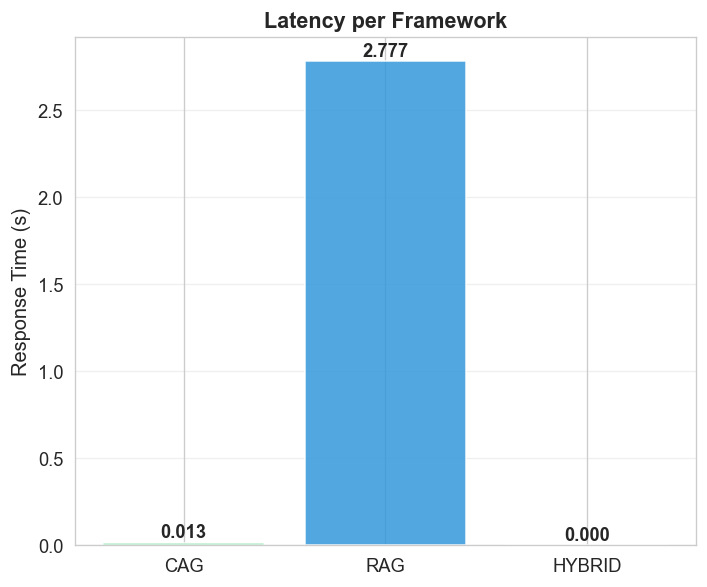

Saved: logs/framework_latency.png


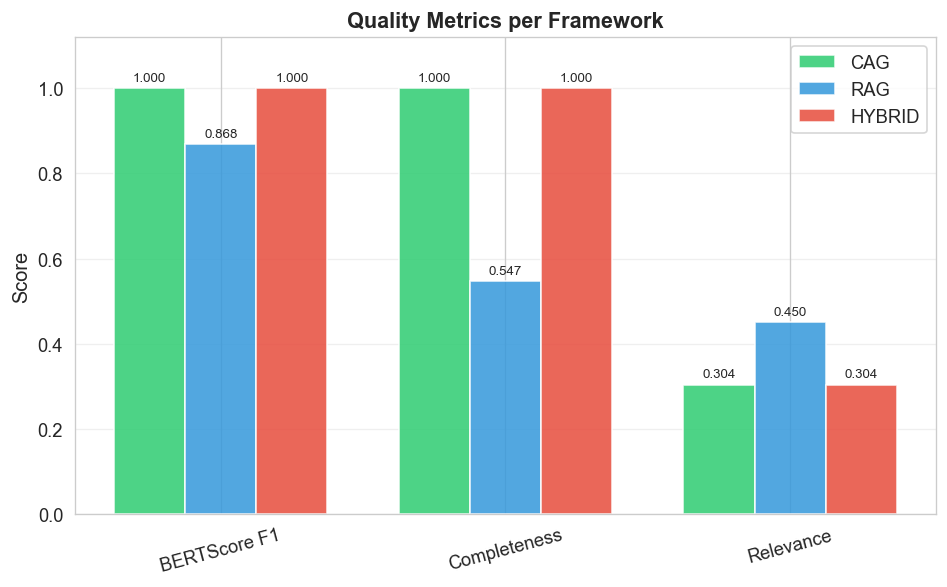

Saved: logs/framework_quality.png


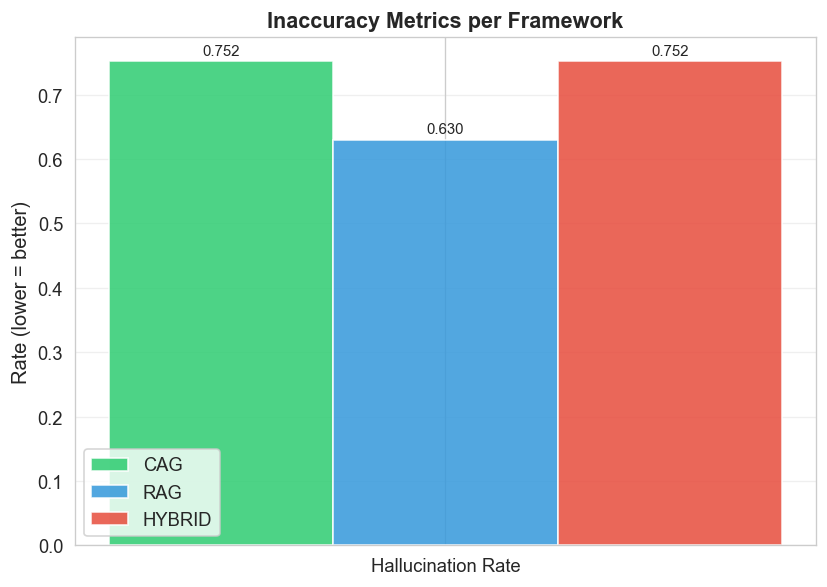

Saved: logs/framework_inaccuracy.png


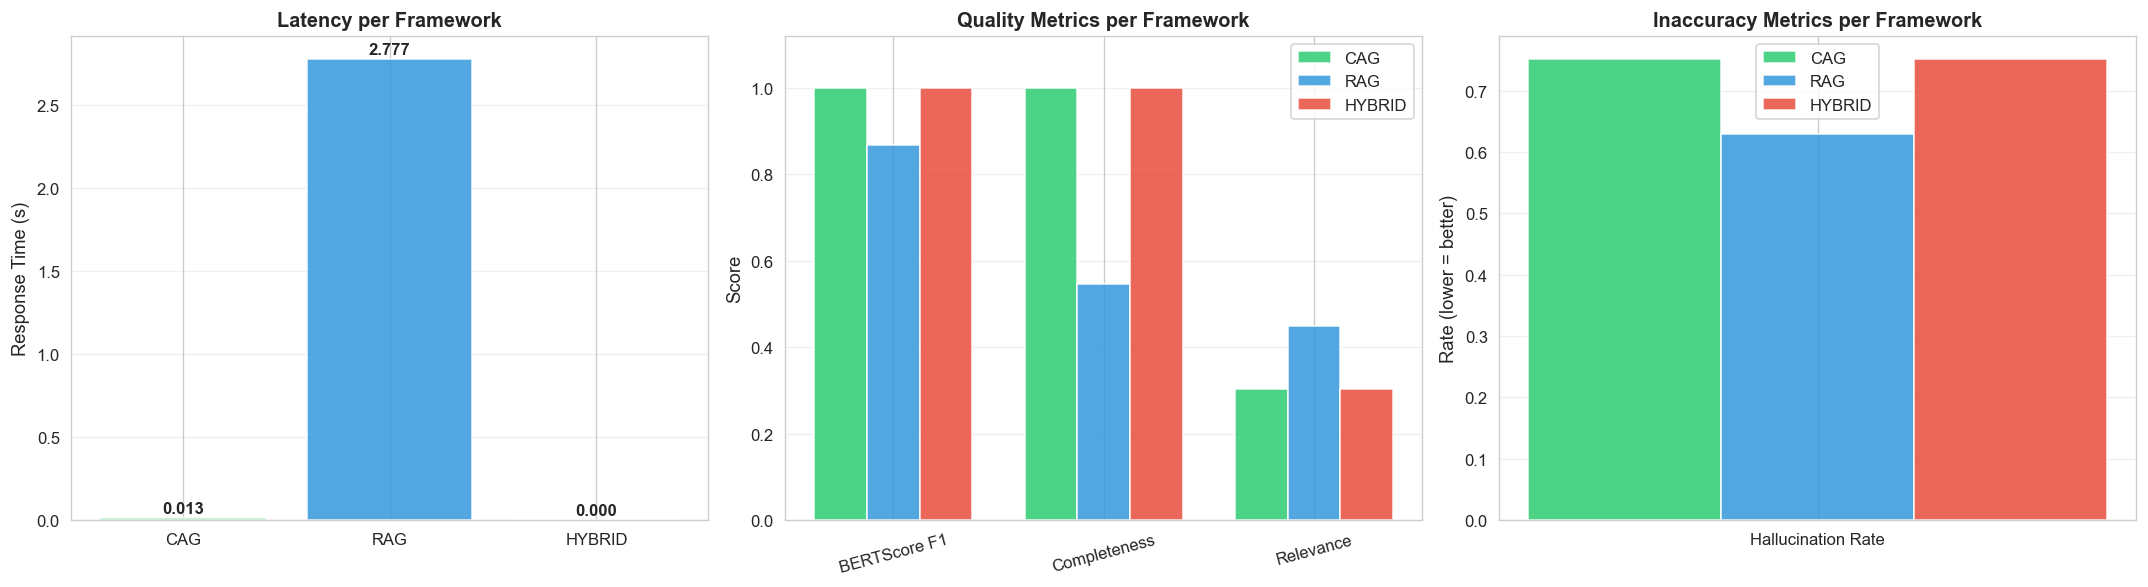

Saved: logs/framework_comparison.png (overview)


In [31]:
# Per-Framework Visualization: CAG vs RAG vs Hybrid
# Setiap panel juga disimpan sebagai gambar mandiri (individual) untuk keperluan paper.

frameworks_available = [f for f in ['CAG', 'RAG', 'HYBRID'] if f in framework_metrics]
colors = {'CAG': '#2ecc71', 'RAG': '#3498db', 'HYBRID': '#e74c3c'}


def _safe(v):
    return 0.0 if v is None or (isinstance(v, float) and np.isnan(v)) else v


def _label(v):
    return "N/A" if v is None or (isinstance(v, float) and np.isnan(v)) else f"{v:.3f}"


width = 0.75 / max(len(frameworks_available), 1)

# ── 1. Latency per Framework (individual figure) ─────────────────────────
fig1, ax1 = plt.subplots(figsize=(6, 5))
times_raw = [framework_metrics[s]['time_avg'] for s in frameworks_available]
times = [_safe(v) for v in times_raw]
bars = ax1.bar(frameworks_available, times,
               color=[colors[s] for s in frameworks_available], alpha=0.85, edgecolor='white')
ax1.set_ylabel('Response Time (s)', fontsize=12)
ax1.set_title('Latency per Framework', fontsize=13, fontweight='bold')
ax1.tick_params(labelsize=11)
for bar, val in zip(bars, times_raw):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             _label(val), ha='center', va='bottom', fontsize=11, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)
fig1.tight_layout()
fig1.savefig('../logs/framework_latency.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: logs/framework_latency.png")

# ── 2. Quality Metrics per Framework (individual figure) ─────────────────
fig2, ax2 = plt.subplots(figsize=(8, 5))
quality_metrics = ['bert', 'comp', 'rel']
quality_labels  = ['BERTScore F1', 'Completeness', 'Relevance']
x_q = np.arange(len(quality_metrics))
for idx, fw in enumerate(frameworks_available):
    raw_vals = [framework_metrics[fw][m] for m in quality_metrics]
    vals = [_safe(v) for v in raw_vals]
    pos = x_q + (idx - (len(frameworks_available) - 1) / 2) * width
    bars2 = ax2.bar(pos, vals, width, label=fw, color=colors[fw], alpha=0.85,
                    edgecolor='white')
    for bar, val in zip(bars2, raw_vals):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 _label(val), ha='center', va='bottom', fontsize=8)
ax2.set_ylabel('Score', fontsize=12)
ax2.set_title('Quality Metrics per Framework', fontsize=13, fontweight='bold')
ax2.set_xticks(x_q)
ax2.set_xticklabels(quality_labels, rotation=15, fontsize=11)
ax2.tick_params(labelsize=11)
ax2.legend(fontsize=11)
ax2.set_ylim(0, 1.12)
ax2.grid(axis='y', alpha=0.3)
fig2.tight_layout()
fig2.savefig('../logs/framework_quality.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: logs/framework_quality.png")

# ── 3. Inaccuracy Metrics per Framework (individual figure) ──────────────
fig3, ax3 = plt.subplots(figsize=(7, 5))
inacc_metrics = ['hall']
inacc_labels  = ['Hallucination Rate']
x_i = np.arange(len(inacc_metrics))
for idx, fw in enumerate(frameworks_available):
    raw_vals = [framework_metrics[fw][m] for m in inacc_metrics]
    vals = [_safe(v) for v in raw_vals]
    pos = x_i + (idx - (len(frameworks_available) - 1) / 2) * width
    bars3 = ax3.bar(pos, vals, width, label=fw, color=colors[fw], alpha=0.85,
                    edgecolor='white')
    for bar, val in zip(bars3, raw_vals):
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 _label(val), ha='center', va='bottom', fontsize=9)
ax3.set_ylabel('Rate (lower = better)', fontsize=12)
ax3.set_title('Inaccuracy Metrics per Framework', fontsize=13, fontweight='bold')
ax3.set_xticks(x_i)
ax3.set_xticklabels(inacc_labels, fontsize=11)
ax3.tick_params(labelsize=11)
ax3.legend(fontsize=11)
ax3.grid(axis='y', alpha=0.3)
fig3.tight_layout()
fig3.savefig('../logs/framework_inaccuracy.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: logs/framework_inaccuracy.png")

# ── Combined overview (3-panel) ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# panel 1: latency
ax = axes[0]
bars = ax.bar(frameworks_available, times, color=[colors[s] for s in frameworks_available], alpha=0.85)
ax.set_ylabel('Response Time (s)', fontsize=11)
ax.set_title('Latency per Framework', fontsize=12, fontweight='bold')
ax.tick_params(labelsize=10)
for bar, val in zip(bars, times_raw):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            _label(val), ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# panel 2: quality
ax = axes[1]
for idx, fw in enumerate(frameworks_available):
    raw_vals = [framework_metrics[fw][m] for m in quality_metrics]
    vals = [_safe(v) for v in raw_vals]
    pos = x_q + (idx - (len(frameworks_available) - 1) / 2) * width
    ax.bar(pos, vals, width, label=fw, color=colors[fw], alpha=0.85)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Quality Metrics per Framework', fontsize=12, fontweight='bold')
ax.set_xticks(x_q)
ax.set_xticklabels(quality_labels, rotation=15, fontsize=10)
ax.legend(fontsize=10)
ax.set_ylim(0, 1.12)
ax.grid(axis='y', alpha=0.3)

# panel 3: inaccuracy
ax = axes[2]
for idx, fw in enumerate(frameworks_available):
    raw_vals = [framework_metrics[fw][m] for m in inacc_metrics]
    vals = [_safe(v) for v in raw_vals]
    pos = x_i + (idx - (len(frameworks_available) - 1) / 2) * width
    ax.bar(pos, vals, width, label=fw, color=colors[fw], alpha=0.85)
ax.set_ylabel('Rate (lower = better)', fontsize=11)
ax.set_title('Inaccuracy Metrics per Framework', fontsize=12, fontweight='bold')
ax.set_xticks(x_i)
ax.set_xticklabels(inacc_labels, fontsize=10)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../logs/framework_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: logs/framework_comparison.png (overview)")


## Latency Analysis (CAG vs RAG vs Hybrid)

Sesi ini membahas perbandingan latensi antar framework untuk 200 query. Tujuannya adalah melihat bukan hanya rata-rata, tetapi juga stabilitas respons per query.

Urutan visual di bawah ini:

1. **Response Time per Query** — timeline waktu respons setiap query untuk CAG, RAG, dan Hybrid
2. **Avg Response Time per Framework** — rata-rata dan deviasi standar tiap framework
3. **Speedup Factor** — perbandingan rata-rata RAG vs CAG, dan RAG vs Hybrid

LATENCY SUMMARY — CAG vs RAG vs HYBRID
  RAG avg time     : 2.777s ± 2.080s
  CAG avg time     : 0.013s ± 0.127s
  Speedup (RAG/CAG): 211.81x
  Hybrid avg time  : 0.000s ± 0.000s
  Speedup (RAG/Hybrid): 23764.54x


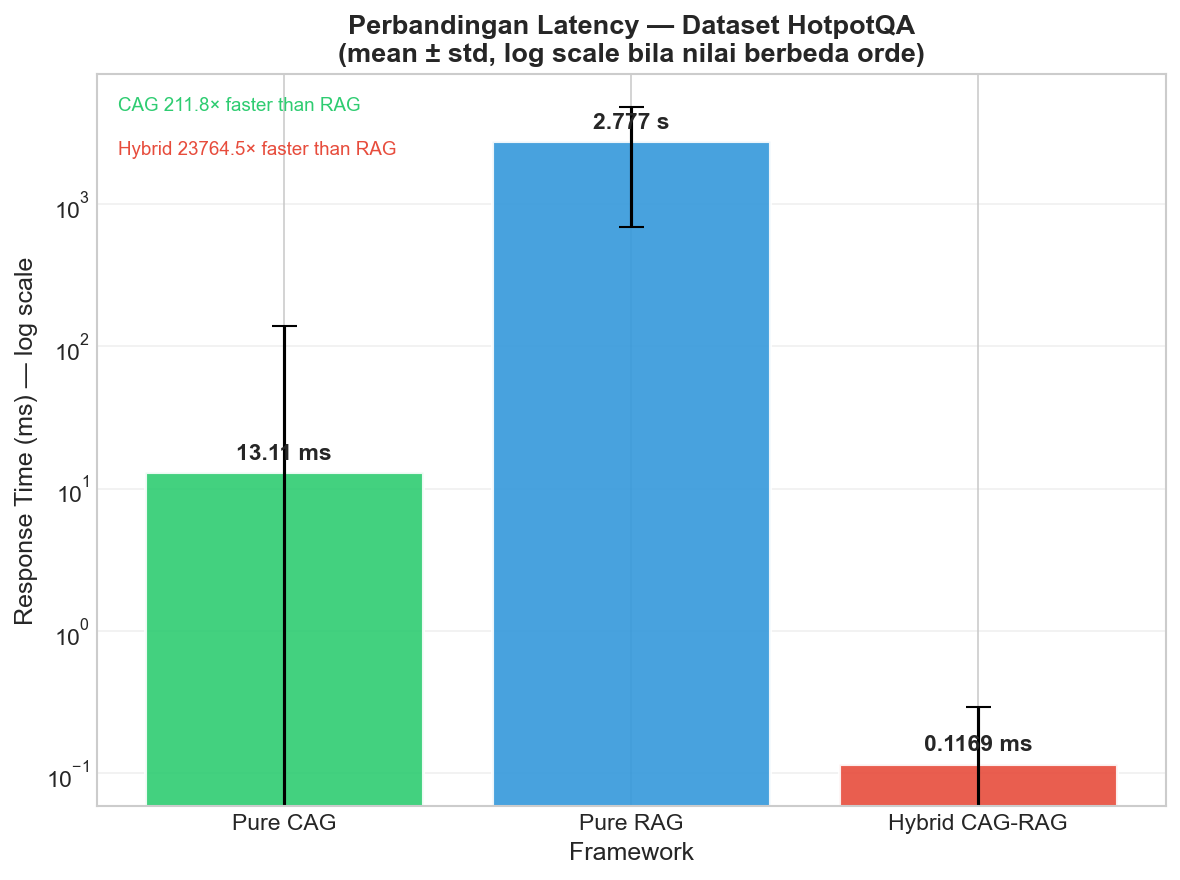

✅ Saved: logs/thesis_charts/hotpotqa_latency.png


In [32]:
# LATENCY ANALYSIS — Framework Comparison (CAG vs RAG vs Hybrid)
# Bar Chart untuk Skripsi

import matplotlib.pyplot as plt
import numpy as np

# Setup style untuk publikasi ilmiah
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.dpi': 150, 'savefig.dpi': 300,
    'font.size': 11, 'axes.titlesize': 14, 'axes.labelsize': 12,
})

# Colors dan Labels
COLORS = {'CAG': '#2ecc71', 'RAG': '#3498db', 'HYBRID': '#e74c3c'}
LABELS = {'CAG': 'Pure CAG', 'RAG': 'Pure RAG', 'HYBRID': 'Hybrid CAG-RAG'}

rag_times     = rag_m['_time']
cag_times     = pure_cag_m['_time'] if pure_cag_m else []
hybrid_times  = cag_m['_time'] if cag_m else []

speedup_cag    = (rag_m['time_avg'] / pure_cag_m['time_avg']) if (pure_cag_m and pure_cag_m['time_avg'] > 0) else None
speedup_hybrid = (rag_m['time_avg'] / cag_m['time_avg']) if (cag_m and cag_m['time_avg'] > 0) else None

print("=" * 65)
print("LATENCY SUMMARY — CAG vs RAG vs HYBRID")
print("=" * 65)
print(f"  RAG avg time     : {rag_m['time_avg']:.3f}s ± {rag_m['time_std']:.3f}s")
if pure_cag_m:
    print(f"  CAG avg time     : {pure_cag_m['time_avg']:.3f}s ± {pure_cag_m['time_std']:.3f}s")
    print(f"  Speedup (RAG/CAG): {speedup_cag:.2f}x" if speedup_cag else "  Speedup (RAG/CAG): N/A")
if cag_m:
    print(f"  Hybrid avg time  : {cag_m['time_avg']:.3f}s ± {cag_m['time_std']:.3f}s")
    print(f"  Speedup (RAG/Hybrid): {speedup_hybrid:.2f}x" if speedup_hybrid else "  Speedup (RAG/Hybrid): N/A")
print("=" * 65)

# ============================================================================
# BAR CHART: Perbandingan Latency (Response Time) - Thesis Ready
# ============================================================================
os.makedirs('../logs/thesis_charts', exist_ok=True)

# Prepare data
frameworks, means, stds, colors_list = [], [], [], []
if pure_cag_m:
    frameworks.append('CAG')
    means.append(float(pure_cag_m['time_avg']))
    stds.append(float(pure_cag_m['time_std']))
    colors_list.append(COLORS['CAG'])
frameworks.append('RAG')
means.append(float(rag_m['time_avg']))
stds.append(float(rag_m['time_std']))
colors_list.append(COLORS['RAG'])
if cag_m:
    frameworks.append('HYBRID')
    means.append(float(cag_m['time_avg']))
    stds.append(float(cag_m['time_std']))
    colors_list.append(COLORS['HYBRID'])

# FIX: helper label — tampilkan ms bila nilai < 0.5s agar "0.000s" tidak muncul
def _fmt_latency(v_sec: float) -> str:
    if v_sec < 0.001:
        return f'{v_sec*1000:.4f} ms'
    elif v_sec < 0.5:
        return f'{v_sec*1000:.2f} ms'
    else:
        return f'{v_sec:.3f} s'

# FIX: konversi semua ke milidetik untuk perbandingan yang adil di satu sumbu
means_ms = [v * 1000 for v in means]
stds_ms  = [v * 1000 for v in stds]

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(
    [LABELS.get(f, f) for f in frameworks], means_ms,
    color=colors_list,
    yerr=stds_ms, capsize=6,
    edgecolor='white', linewidth=1.5, alpha=0.9
)

# FIX: gunakan log-scale agar bar Hybrid (ms) tetap kelihatan di
# samping bar RAG (detik) — perbedaan bisa 3 orde besaran
any_near_zero = any(v < 1.0 for v in means_ms)
if any_near_zero:
    ax.set_yscale('log')
    ax.set_ylabel('Response Time (ms) — log scale', fontsize=12)
    # Pastikan y-min tidak 0 agar log scale valid
    ax.set_ylim(bottom=max(0.001, min(means_ms) * 0.5))
else:
    ax.set_ylabel('Response Time (ms)', fontsize=12)

# FIX: label selalu tampil dengan nilai yang terbaca (ms / s)
for bar, v_orig in zip(bars, means):
    label_txt = _fmt_latency(v_orig)
    y_pos = bar.get_height()
    # Untuk log scale, offset relatif agar label tidak overlap
    y_offset = y_pos * 1.15 if any_near_zero else y_pos + max(stds_ms) * 0.05 + 0.5
    ax.text(bar.get_x() + bar.get_width() / 2, y_offset,
            label_txt, ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_xlabel('Framework', fontsize=12)
ax.set_title('Perbandingan Latency — Dataset HotpotQA\n(mean ± std, log scale bila nilai berbeda orde)',
             fontsize=13, fontweight='bold')
ax.tick_params(axis='x', labelsize=11)
ax.grid(axis='y', alpha=0.3)

# FIX: speedup annotation tetap ditampilkan
if speedup_cag and speedup_hybrid:
    ax.annotate(f'CAG {speedup_cag:.1f}× faster than RAG',
                xy=(0.02, 0.95), xycoords='axes fraction', fontsize=9, color='#2ecc71')
    ax.annotate(f'Hybrid {speedup_hybrid:.1f}× faster than RAG',
                xy=(0.02, 0.89), xycoords='axes fraction', fontsize=9, color='#e74c3c')

plt.tight_layout()
plt.savefig('../logs/thesis_charts/hotpotqa_latency.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig('../logs/avg_response_time_frameworks.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: logs/thesis_charts/hotpotqa_latency.png")

## Retrieval Inaccuracy Metrics (CAG vs RAG vs Hybrid)

Sesi ini menampilkan metrik Retrieval Inaccuracy sesuai daftar evaluasi utama. Semua metrik berikut tetap dihitung pada pipeline evaluasi:
- Relevance Score
- Exact Match (EM)
- Effective Information Rate (EIR)
- RAG Recall
- BERTScore F1
- Completeness
- Hallucination Rate

Agar pembacaan lebih fokus, visualisasi dibagi menjadi beberapa panel, tetapi tetap berada dalam section Retrieval Inaccuracy.

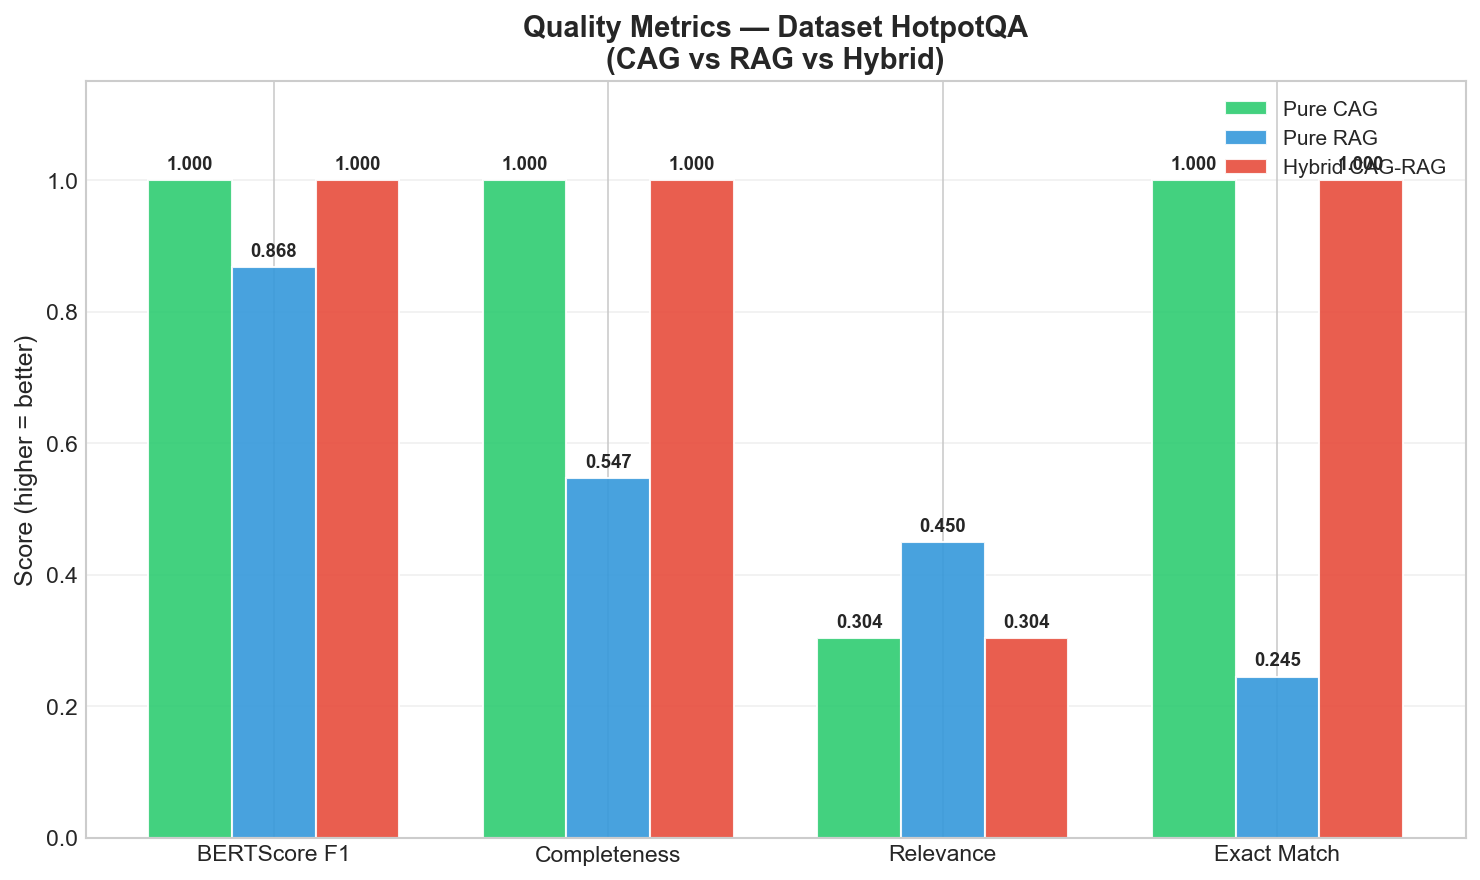

✅ Saved: logs/thesis_charts/hotpotqa_quality_metrics.png


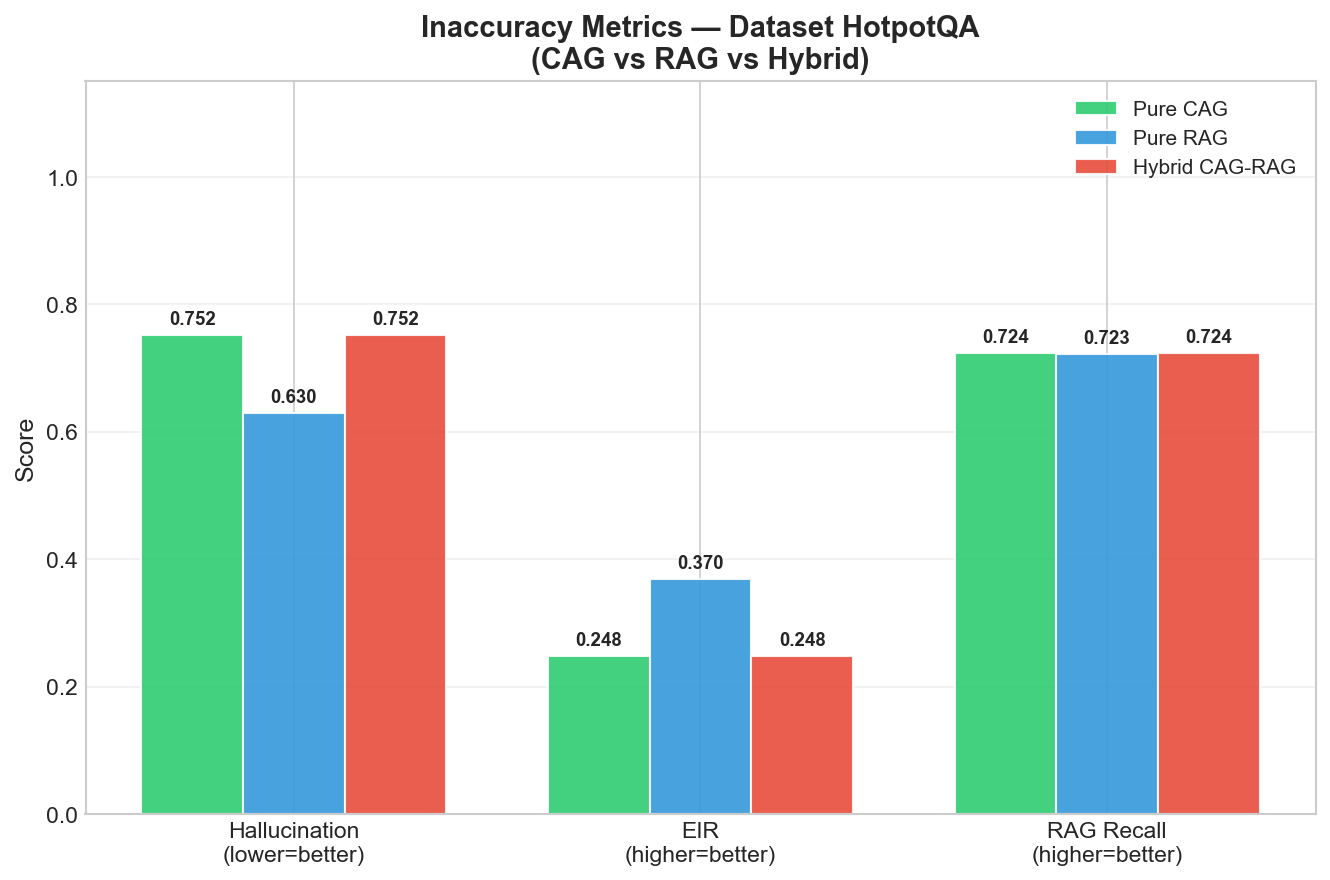

✅ Saved: logs/thesis_charts/hotpotqa_inaccuracy_metrics.png


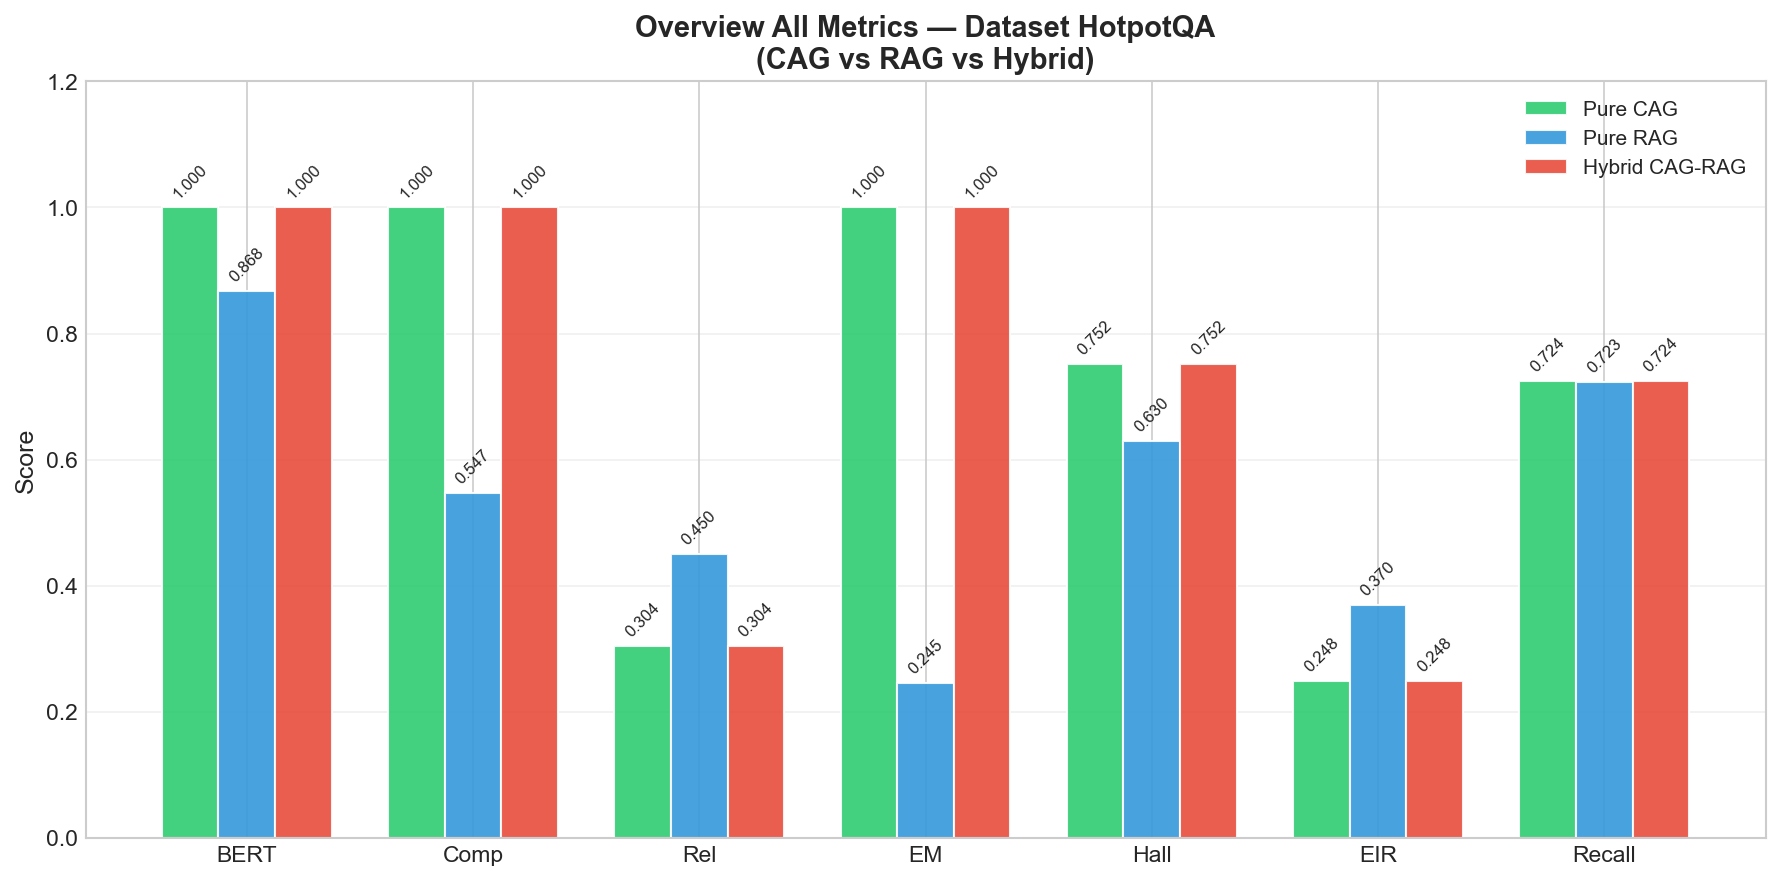

✅ Saved: logs/thesis_charts/hotpotqa_all_metrics.png


In [33]:
# RETRIEVAL INACCURACY VISUALIZATION — Framework Comparison (Bar Charts untuk Thesis)
# Dibagi menjadi beberapa panel: Quality Metrics, Inaccuracy Metrics, dan Overview

import matplotlib.pyplot as plt
import numpy as np

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.dpi': 150, 'savefig.dpi': 300, 'font.size': 11})

COLORS = {'CAG': '#2ecc71', 'RAG': '#3498db', 'HYBRID': '#e74c3c'}
LABELS = {'CAG': 'Pure CAG', 'RAG': 'Pure RAG', 'HYBRID': 'Hybrid CAG-RAG'}

framework_metrics = {'CAG': pure_cag_m, 'RAG': rag_m, 'HYBRID': cag_m}
frameworks = [f for f in ['CAG', 'RAG', 'HYBRID'] if framework_metrics.get(f)]
width = 0.25

def _safe(v):
    return 0.0 if v is None or (isinstance(v, float) and np.isnan(v)) else v

def _label(v):
    if v is None or (isinstance(v, float) and np.isnan(v)):
        return "N/A*"
    return f"{v:.3f}"

# Catatan: N/A* berarti BERTScore gagal load model BERT; nilai yang ditampilkan
# adalah hasil token-overlap F1 fallback (lihat bertscore_f1 di atas).
# Jika model berhasil load, label akan menampilkan nilai numerik.

# ============================================================================
# CHART 1: Quality Metrics (BERTScore, Completeness, Relevance, Exact Match)
# ============================================================================
quality_keys = ['bert', 'comp', 'rel', 'em']
quality_labels = ['BERTScore F1', 'Completeness', 'Relevance', 'Exact Match']

fig1, ax1 = plt.subplots(figsize=(10, 6))
x = np.arange(len(quality_keys))

for idx, fw in enumerate(frameworks):
    vals = [_safe(framework_metrics[fw].get(k)) for k in quality_keys]
    raw_vals = [framework_metrics[fw].get(k) for k in quality_keys]
    pos = x + (idx - (len(frameworks)-1)/2) * width
    bars = ax1.bar(pos, vals, width, label=LABELS[fw], color=COLORS[fw], edgecolor='white', alpha=0.9)
    for bar, v_raw in zip(bars, raw_vals):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 _label(v_raw), ha='center', va='bottom', fontsize=9, fontweight='bold')

ax1.set_xticks(x)
ax1.set_xticklabels(quality_labels, fontsize=11)
ax1.set_ylabel('Score (higher = better)', fontsize=12)
ax1.set_title('Quality Metrics — Dataset HotpotQA\n(CAG vs RAG vs Hybrid)', fontsize=14, fontweight='bold')
ax1.set_ylim(0, 1.15)
ax1.legend(fontsize=10, loc='upper right')
ax1.grid(axis='y', alpha=0.3)
fig1.tight_layout()
fig1.savefig('../logs/thesis_charts/hotpotqa_quality_metrics.png', dpi=300, bbox_inches='tight', facecolor='white')
fig1.savefig('../logs/retrieval_inaccuracy_metrics_part3.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: logs/thesis_charts/hotpotqa_quality_metrics.png")

# ============================================================================
# CHART 2: Inaccuracy Metrics (Hallucination, EIR, RAG Recall)
# ============================================================================
inaccuracy_keys = ['hall', 'eir', 'recall']
inaccuracy_labels = ['Hallucination\n(lower=better)', 'EIR\n(higher=better)', 'RAG Recall\n(higher=better)']

fig2, ax2 = plt.subplots(figsize=(9, 6))
x2 = np.arange(len(inaccuracy_keys))

for idx, fw in enumerate(frameworks):
    vals = [_safe(framework_metrics[fw].get(k)) for k in inaccuracy_keys]
    raw_vals = [framework_metrics[fw].get(k) for k in inaccuracy_keys]
    pos = x2 + (idx - (len(frameworks)-1)/2) * width
    bars = ax2.bar(pos, vals, width, label=LABELS[fw], color=COLORS[fw], edgecolor='white', alpha=0.9)
    for bar, v_raw in zip(bars, raw_vals):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 _label(v_raw), ha='center', va='bottom', fontsize=9, fontweight='bold')

ax2.set_xticks(x2)
ax2.set_xticklabels(inaccuracy_labels, fontsize=11)
ax2.set_ylabel('Score', fontsize=12)
ax2.set_title('Inaccuracy Metrics — Dataset HotpotQA\n(CAG vs RAG vs Hybrid)', fontsize=14, fontweight='bold')
ax2.set_ylim(0, 1.15)
ax2.legend(fontsize=10, loc='upper right')
ax2.grid(axis='y', alpha=0.3)
fig2.tight_layout()
fig2.savefig('../logs/thesis_charts/hotpotqa_inaccuracy_metrics.png', dpi=300, bbox_inches='tight', facecolor='white')
fig2.savefig('../logs/retrieval_inaccuracy_metrics_part1.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: logs/thesis_charts/hotpotqa_inaccuracy_metrics.png")

# ============================================================================
# CHART 3: All Metrics Overview (untuk gambar ringkas dalam skripsi)
# ============================================================================
all_keys = ['bert', 'comp', 'rel', 'em', 'hall', 'eir', 'recall']
all_labels = ['BERT', 'Comp', 'Rel', 'EM', 'Hall', 'EIR', 'Recall']

fig3, ax3 = plt.subplots(figsize=(12, 6))
x3 = np.arange(len(all_keys))

for idx, fw in enumerate(frameworks):
    vals = [_safe(framework_metrics[fw].get(k)) for k in all_keys]
    raw_vals = [framework_metrics[fw].get(k) for k in all_keys]
    pos = x3 + (idx - (len(frameworks)-1)/2) * width
    bars = ax3.bar(pos, vals, width, label=LABELS[fw], color=COLORS[fw], edgecolor='white', alpha=0.9)
    for bar, v_raw in zip(bars, raw_vals):
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 _label(v_raw), ha='center', va='bottom', fontsize=8, rotation=45)

ax3.set_xticks(x3)
ax3.set_xticklabels(all_labels, fontsize=11)
ax3.set_ylabel('Score', fontsize=12)
ax3.set_title('Overview All Metrics — Dataset HotpotQA\n(CAG vs RAG vs Hybrid)', fontsize=14, fontweight='bold')
ax3.set_ylim(0, 1.2)
ax3.legend(fontsize=10, loc='upper right')
ax3.grid(axis='y', alpha=0.3)
fig3.tight_layout()
fig3.savefig('../logs/thesis_charts/hotpotqa_all_metrics.png', dpi=300, bbox_inches='tight', facecolor='white')
fig3.savefig('../logs/retrieval_inaccuracy_metrics_overview.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: logs/thesis_charts/hotpotqa_all_metrics.png")

# Store results for cross-dataset comparison
HOTPOTQA_RESULTS = {
    'CAG': pure_cag_m,
    'RAG': rag_m,
    'HYBRID': cag_m
}

## Statistical Significance Testing
Paired t-test (p < 0.05) + Cohen's d effect size.

🔬 STATISTICAL SIGNIFICANCE TESTS (Paired t-test, NaN-aware)
   H0: No difference between RAG and Hybrid CAG-RAG
   H1: Significant difference exists (p < 0.05)
   NaN positions (no-context path) are excluded from all tests.

  Metric                     N   RAG µ   CAG µ   t-stat   p-value       d  Result
  ----------------------------------------------------------------------------------
  Response Time            200  2.7771  0.0001   18.831    0.0000   1.332  ✅ H1 supported
  Relevance Score          200  0.4500  0.3038    8.011    0.0000   0.567  ⚠️  sig. but reversed
  Exact Match              200  0.2450  1.0000  -24.764    0.0000  -1.751  ✅ H1 supported
  EIR                      200  0.3698  0.2483    7.572    0.0000   0.535  ⚠️  sig. but reversed
  RAG Recall              182*  0.7225  0.7244   -0.052    0.9583  -0.004  ❌ not significant
  BERTScore F1             200  0.8679  1.0000  -24.093    0.0000  -1.704  ✅ H1 supported
  Completeness            182*  0.5469  1.0000  -13

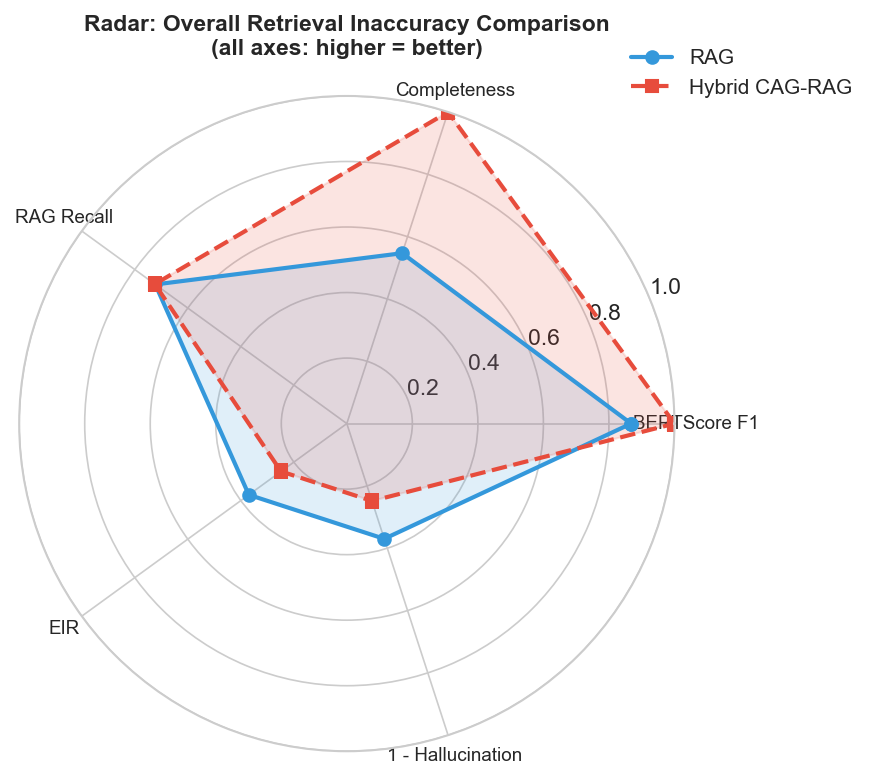

✅ Saved: logs/radar_comparison.png


In [34]:
# 🔬 STATISTICAL SIGNIFICANCE TESTING  (Paired t-test + Cohen's d)
if not cag_m:
    print("⚠️  CAG results not available, skipping statistical tests.")
else:
    print("=" * 72)
    print("🔬 STATISTICAL SIGNIFICANCE TESTS (Paired t-test, NaN-aware)")
    print("   H0: No difference between RAG and Hybrid CAG-RAG")
    print("   H1: Significant difference exists (p < 0.05)")
    print("   NaN positions (no-context path) are excluded from all tests.")
    print("=" * 72)

    # Metrik yang diuji — arah = 'lower' → CAG harus lebih rendah, 'higher' → CAG harus lebih tinggi
    # EM/BERTScore/Completeness tetap dianggap sebagai bagian dari retrieval inaccuracy / answer alignment.
    test_metrics = [
        # (label,              rag_list,             cag_list,             better_direction)
        # ── Latency ──────────────────────────────────────────────────────────
        ("Response Time",      rag_m['_time'],       cag_m['_time'],       "lower"),
        # ── Relevance ─────────────────────────────────────────────────────────
        ("Relevance Score",    rag_m['_rel'],        cag_m['_rel'],        "higher"),
        # ── Retrieval / Answer Alignment ─────────────────────────────────────
        ("Exact Match",        rag_m['_em'],         cag_m['_em'],         "higher"),
        ("EIR",                rag_m['_eir'],        cag_m['_eir'],        "higher"),
        ("RAG Recall",         rag_m['_recall'],     cag_m['_recall'],     "higher"),
        ("BERTScore F1",       rag_m['_bert'],       cag_m['_bert'],       "higher"),
        ("Completeness",       rag_m['_comp'],       cag_m['_comp'],       "higher"),
        # ── Inaccuracy ────────────────────────────────────────────────────────
        ("Hallucination Rate", rag_m['_hall'],       cag_m['_hall'],       "lower"),
    ]

    stat_rows = []
    print(f"\n  {'Metric':<22} {'N':>5} {'RAG µ':>7} {'CAG µ':>7} {'t-stat':>8} {'p-value':>9} {'d':>7}  Result")
    print("  " + "-" * 82)

    for lbl, rag_vals, cag_vals, direction in test_metrics:
        if len(rag_vals) < 2 or len(cag_vals) < 2:
            print(f"  {lbl:<22}  (insufficient data — need ≥ 2 queries)")
            continue

        t_stat, p_val, n_valid = paired_ttest(rag_vals, cag_vals)
        d                      = cohens_d(rag_vals, cag_vals)

        if n_valid < 2:
            print(f"  {lbl:<22}  (no valid pairs after NaN removal — skipped)")
            continue

        # Means computed only on non-NaN values for fair representation
        rag_clean = [x for x in rag_vals if not (isinstance(x, float) and np.isnan(x))]
        cag_clean = [x for x in cag_vals if not (isinstance(x, float) and np.isnan(x))]
        rag_mu    = round(float(np.mean(rag_clean)), 4) if rag_clean else float('nan')
        cag_mu    = round(float(np.mean(cag_clean)), 4) if cag_clean else float('nan')

        significant = not np.isnan(p_val) and p_val < 0.05

        # Check if direction is as expected
        if direction == "lower":
            direction_ok = cag_mu <= rag_mu
        else:
            direction_ok = cag_mu >= rag_mu

        if significant and direction_ok:
            result = "✅ H1 supported"
        elif significant and not direction_ok:
            result = "⚠️  sig. but reversed"
        else:
            result = "❌ not significant"

        n_str = f"{n_valid}" if n_valid == len(rag_vals) else f"{n_valid}*"
        print(f"  {lbl:<22} {n_str:>5} {rag_mu:>7.4f} {cag_mu:>7.4f} "
              f"{t_stat:>8.3f} {p_val:>9.4f} {d:>7.3f}  {result}")
        stat_rows.append({
            'Metric': lbl, 'N': n_valid, 'RAG_mean': rag_mu, 'CAG_mean': cag_mu,
            't_stat': t_stat, 'p_value': p_val, "Cohen_d": d,
            'significant': significant, 'direction_ok': direction_ok
        })

    print("\n  * N < total = beberapa posisi NaN (no-context path) dikecualikan")
    print("  Legend: ✅ Hypothesis supported  |  ❌ Not significant  |  ⚠️  Unexpected direction")
    print(f"  α = 0.05  |  Effect size: small < 0.2,  medium 0.2–0.8,  large > 0.8")

    # Radar chart for visual comparison
    stat_df = pd.DataFrame(stat_rows)

    # Radar chart
    radar_metrics = ['BERTScore F1', 'Completeness', 'RAG Recall', 'EIR']
    rag_radar  = [rag_m['bert'], rag_m['comp'], rag_m['recall'], rag_m['eir']]
    cag_radar  = [cag_m['bert'], cag_m['comp'], cag_m['recall'], cag_m['eir']]

    # Invert inaccuracy metrics so higher = better on radar
    # Guard against NaN for hallucination (no-context path excluded from mean already)
    rag_hall_val = rag_m['hall'] if not (isinstance(rag_m['hall'], float) and np.isnan(rag_m['hall'])) else 0.5
    cag_hall_val = cag_m['hall'] if not (isinstance(cag_m['hall'], float) and np.isnan(cag_m['hall'])) else 0.5

    radar_metrics += ['1 - Hallucination']
    rag_radar  += [1 - rag_hall_val]
    cag_radar  += [1 - cag_hall_val]

    # Replace any remaining NaN with 0 for radar chart rendering
    rag_radar = [v if not (isinstance(v, float) and np.isnan(v)) else 0.0 for v in rag_radar]
    cag_radar = [v if not (isinstance(v, float) and np.isnan(v)) else 0.0 for v in cag_radar]

    N   = len(radar_metrics)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    rag_r  = rag_radar + [rag_radar[0]]
    cag_r  = cag_radar + [cag_radar[0]]
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
    ax.plot(angles, rag_r, 'o-', color='#3498db', linewidth=2, label='RAG')
    ax.fill(angles, rag_r, alpha=0.15, color='#3498db')
    ax.plot(angles, cag_r, 's--', color='#e74c3c', linewidth=2, label='Hybrid CAG-RAG')
    ax.fill(angles, cag_r, alpha=0.15, color='#e74c3c')
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_metrics, fontsize=9)
    ax.set_ylim(0, 1)
    ax.set_title('Radar: Overall Retrieval Inaccuracy Comparison\n(all axes: higher = better)',
                 fontsize=11, fontweight='bold', pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)
    plt.tight_layout()
    plt.savefig('../logs/radar_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✅ Saved: logs/radar_comparison.png")

## Save & Export

In [35]:
# Save & Export All Results

import json
ts = datetime.now().strftime('%Y%m%d_%H%M%S')
os.makedirs('../logs', exist_ok=True)

speedup_hybrid = (rag_m['time_avg'] / cag_m['time_avg']) if (cag_m and cag_m['time_avg'] > 0) else None
speedup_cag    = (rag_m['time_avg'] / pure_cag_m['time_avg']) if (pure_cag_m and pure_cag_m['time_avg'] > 0) else None

cag_hits = sum(1 for x in pure_cag_res if x.get('cache')) if pure_cag_res else 0
hybrid_hits = sum(1 for x in cag_res if x.get('cache')) if cag_res else 0

# 1. Summary metrics JSON
summary_export = {
    'timestamp':    ts,
    'dataset_size': len(dataset),
    'rag': {k: v for k, v in rag_m.items() if not k.startswith('_') and k != 'per_query'},
    'cag_pure': ({k: v for k, v in pure_cag_m.items() if not k.startswith('_') and k != 'per_query'}
                 if pure_cag_m else None),
    'hybrid': ({k: v for k, v in cag_m.items() if not k.startswith('_') and k != 'per_query'}
               if cag_m else None),
    'speedup_hybrid': round(speedup_hybrid, 4) if speedup_hybrid else None,
    'speedup_cag': round(speedup_cag, 4) if speedup_cag else None,
    'cache_hits': {
        'cag_pure': cag_hits,
        'hybrid': hybrid_hits,
    },
}

json_path = f'../logs/eval_summary_{ts}.json'
with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(summary_export, f, indent=2, ensure_ascii=False)
print(f"Summary JSON     : {json_path}")

# 2. Per-query CSV — RAG
if rag_m['per_query']:
    rag_csv = f'../logs/eval_rag_perquery_{ts}.csv'
    pd.DataFrame(rag_m['per_query']).to_csv(rag_csv, index=False)
    print(f"RAG per-query    : {rag_csv}")

# 3. Per-query CSV — CAG (pure)
if pure_cag_m and pure_cag_m['per_query']:
    cag_csv = f'../logs/eval_cag_pure_perquery_{ts}.csv'
    pd.DataFrame(pure_cag_m['per_query']).to_csv(cag_csv, index=False)
    print(f"CAG per-query    : {cag_csv}")

# 4. Per-query CSV — Hybrid
if cag_m and cag_m['per_query']:
    hybrid_csv = f'../logs/eval_hybrid_perquery_{ts}.csv'
    pd.DataFrame(cag_m['per_query']).to_csv(hybrid_csv, index=False)
    print(f"Hybrid per-query : {hybrid_csv}")

# 5. Statistical results CSV
if cag_m and 'stat_df' in dir():
    stat_csv = f'../logs/eval_stats_{ts}.csv'
    stat_df.to_csv(stat_csv, index=False)
    print(f"Statistics       : {stat_csv}")

# Key Findings
print("\n" + "=" * 65)
print("KEY FINDINGS  —  CAG vs RAG vs Hybrid CAG-RAG")
print("=" * 65)

print(f"\n  RQ1 LATENCY")
if pure_cag_m:
    print(f"    CAG avg time   : {pure_cag_m['time_avg']:.3f}s +/- {pure_cag_m['time_std']:.3f}s")
    print(f"    CAG CHR        : {pure_cag_m['chr']:.1f}% ({cag_hits}/{len(pure_cag_res)})")
print(f"    RAG avg time   : {rag_m['time_avg']:.3f}s +/- {rag_m['time_std']:.3f}s")
if cag_m:
    print(f"    Hybrid avg time: {cag_m['time_avg']:.3f}s +/- {cag_m['time_std']:.3f}s")
    print(f"    Speedup (RAG/Hybrid): {speedup_hybrid:.2f}x" if speedup_hybrid else "    Speedup (RAG/Hybrid): N/A")
    print(f"    Hybrid CHR     : {cag_m['chr']:.1f}% ({hybrid_hits}/{len(cag_res)})")

print(f"\n  RQ2 INACCURACY")
if cag_m:
    hall_d = rag_m['hall'] - cag_m['hall']
    rel_d  = cag_m['rel']  - rag_m['rel']
    print(f"    Hallucination  RAG={rag_m['hall']:.4f}  Hybrid={cag_m['hall']:.4f}  delta={hall_d:+.4f}")
    print(f"    Relevance      RAG={rag_m['rel']:.4f}  Hybrid={cag_m['rel']:.4f}  delta={rel_d:+.4f}")

    print(f"\n  GROUND-TRUTH ALIGNMENT")
    print(f"    BERTScore F1   RAG={rag_m['bert']:.4f}  Hybrid={cag_m['bert']:.4f}  delta={cag_m['bert']-rag_m['bert']:+.4f}")
    print(f"    Completeness   RAG={rag_m['comp']:.4f}  Hybrid={cag_m['comp']:.4f}  delta={cag_m['comp']-rag_m['comp']:+.4f}")
    print(f"    Exact Match    RAG={rag_m['em']:.4f}  Hybrid={cag_m['em']:.4f}  delta={cag_m['em']-rag_m['em']:+.4f}")

print("\nEvaluation complete.")
print(f"Outputs saved to: logs/")

Summary JSON     : ../logs/eval_summary_20260604_114657.json
RAG per-query    : ../logs/eval_rag_perquery_20260604_114657.csv
CAG per-query    : ../logs/eval_cag_pure_perquery_20260604_114657.csv
Hybrid per-query : ../logs/eval_hybrid_perquery_20260604_114657.csv
Statistics       : ../logs/eval_stats_20260604_114657.csv

KEY FINDINGS  —  CAG vs RAG vs Hybrid CAG-RAG

  RQ1 LATENCY
    CAG avg time   : 0.013s +/- 0.127s
    CAG CHR        : 1.0% (200/200)
    RAG avg time   : 2.777s +/- 2.080s
    Hybrid avg time: 0.000s +/- 0.000s
    Speedup (RAG/Hybrid): 23764.54x
    Hybrid CHR     : 1.0% (200/200)

  RQ2 INACCURACY
    Hallucination  RAG=0.6302  Hybrid=0.7517  delta=-0.1215
    Relevance      RAG=0.4500  Hybrid=0.3038  delta=-0.1462

  GROUND-TRUTH ALIGNMENT
    BERTScore F1   RAG=0.8679  Hybrid=1.0000  delta=+0.1321
    Completeness   RAG=0.5469  Hybrid=1.0000  delta=+0.4531
    Exact Match    RAG=0.2450  Hybrid=1.0000  delta=+0.7550

Evaluation complete.
Outputs saved to: logs/
